In [98]:
# Import pandas library
import pandas as pd
import os
import numpy as np

# Define the folder names
folder1 = "mapping"
folder2 = "actual_order_all"

# Get the list of CSV files in each folder
files1 = [f for f in os.listdir(folder1) if f.endswith(".csv")]
files2 = [f for f in os.listdir(folder2) if f.endswith(".csv")]

# Create an empty dictionary to store the data frames
dataframes = {}

# Loop through the files in folder1
for file1 in files1:
    # Get the prefix of the file name
    prefix1 = file1[:3]
    # Check if the prefix is a number between 100 and 200
    if prefix1.isdigit() and 100 <= int(prefix1) <= 200:
        # Load the CSV file into a data frame
        df1 = pd.read_csv(os.path.join(folder1, file1))
        # Select only the column that you want from the data frame
        df1 = df1[["object_order", "location_x", "location_z"]]
        # Extract the required columns
        df_object_order = df1['object_order']
        df_location_x = df1['location_x']
        df_location_z = df1['location_z']

        # Remove cells with '-' value
        # Reset the index
        df_object_order = df_object_order[df_object_order != '-'].reset_index(drop=True)
        df_location_x = df_location_x[df_location_x != '-'].reset_index(drop=True)
        df_location_z = df_location_z[df_location_z != '-'].reset_index(drop=True)

        # Combine them into a single DataFrame
        df1 = pd.concat([df_object_order, df_location_x, df_location_z], axis=1)
        # Add a column to indicate the source folder and file name
        df1["source"] = folder1 + "/" + file1
        # Remove the cells that contain '-' or 'NaN'
        #df1 = df1.replace("-", pd.NA).dropna()
        # Store the data frame in the dictionary with the file name as the key
        dataframes[file1] = df1

# Loop through the files in folder2
for file2 in files2:
    # Get the prefix of the file name
    prefix2 = file2[:3]
    # Check if the prefix is a number between 100 and 200
    if prefix2.isdigit() and 100 <= int(prefix2) <= 200:
        # Load the CSV file into a data frame
        df2 = pd.read_csv(os.path.join(folder2, file2))
        # Select only the columns that you want from the data frame
        df2 = df2[["Event", "object_name", "group", "time", "location_x", "location_z"]]
        print (df2)
        df2["Event"] = df2["Event"].iloc[2:-1]
        df2["Event"] = df2["Event"].str[7:9]
        df2["Event"] = pd.to_numeric(df2["Event"], errors='coerce')
        df2 = df2.rename(columns={"Event": "object_loc"})
        print (df2)
        # Add a column to indicate the source folder and file name
        df2["source"] = folder2 + "/" + file2
        # Remove the cells that contain '-' or 'NaN'
        df2 = df2.replace("-", pd.NA).dropna()
        # Store the data frame in the dictionary with the file name as the key
        dataframes[file2] = df2
        print (df2)

# Create an empty dictionary to store the new data frames
new_dataframes = {}

# Loop through the keys in the dataframes dictionary
for key in dataframes.keys():
    # Check if the key is a CSV file name
    if key.endswith(".csv"):
        # Get the prefix of the file name
        prefix = key[:3]
        # Check if the prefix is a number between 100 and 200
        if prefix.isdigit() and 100 <= int(prefix) <= 200:
            # Get the data frame corresponding to the key
            df = dataframes[key]
            # Check if the data frame has the 'Entered word' column
            if "object_order" in df.columns:
                # Rename the column to 'entered_word' for consistency
                df = df.rename(columns={"location_x": "input_location_x", "location_z": "input_location_z"})
                # Convert the column values to lower case for matching
                df["object_order"] = df["object_order"].str.lower()
                print (df)
                # Find the matching data frame that has the 'object_name' column and the same prefix
                match_key = prefix + "_actual_order.csv"
                match_df = dataframes[match_key]
                # Convert the column values to lower case for matching
                match_df["object_name"] = match_df["object_name"].str.lower()
                # Merge the two data frames on the common values between 'entered_word' and 'object_name'
                new_df = pd.merge(df, match_df, left_on="object_order", right_on="object_name")
                # Drop the redundant columns from the new data frame
                new_df = new_df.drop(columns=["object_name", "source_x", "source_y"])
                #new_df = new_df.drop(columns=["object_name"])
                # Add another column that calculates distance between two consecutive values using 'location_x' and 'location_z' values, and put first value as 0.
                #new_df["location_x"] = new_df["location_x"].astype(float)
                #new_df["location_z"] = new_df["location_z"].astype(float)
                new_df["actual_location_x"] = new_df["location_x"].astype(float)
                new_df["actual_location_z"] = new_df["location_z"].astype(float)
                new_df["location_x"] = -new_df["actual_location_z"].astype(float)
                new_df["location_z"] = new_df["actual_location_x"].astype(float)
                new_df["input_location_x"] = new_df["input_location_x"].astype(float)
                new_df["input_location_z"] = new_df["input_location_z"].astype(float)

                new_df["actual_distance_conseq_diff"] = ((new_df["location_x"].diff())**2 + (new_df["location_z"].diff())**2)**0.5
                #new_df["actual_distance_conseq_diff"].iloc[0] = 0
                
                new_df["input_distance_conseq_diff"] = ((new_df["input_location_x"].diff())**2 + (new_df["input_location_z"].diff())**2)**0.5
                #new_df["input_distance_conseq_diff"].iloc[0] = 0
                
                new_df['distance'] = np.sqrt((new_df['location_x'] - new_df['input_location_x'])**2 + (new_df['location_z'] - new_df['input_location_z'])**2)
                
                # Create a new series that contains the previous values of the 'time' column
                prev_time = new_df['time'].shift()

                # Compare the original series and the shifted series and get a boolean result
                is_same = new_df['time'] == prev_time

                # Assign labels based on the boolean result
                labels = {True: 'same', False: 'different'}

                # Create a new column that stores the labels
                new_df['label'] = is_same.map(labels)

                # Store 'none' as the first value of the new column
                #new_df['label'].iloc[0] = 'none'

                
                # Store the new data frame in the dictionary with the prefix as the key
                new_dataframes[prefix] = new_df

# Print the number of new data frames created
print(f"Created {len(new_dataframes)} new data frames.")


                               Event object_name group time location_x  \
0   location list generation started           -     -    -          -   
1          Object randomization seed           -     -    -          -   
2                       Object 0 is:      statue     C    2         16   
3                       Object 1 is:        cone     A    1         50   
4                       Object 2 is:        lamp     B    1         57   
5                       Object 3 is:     hydrant     D    2         25   
6                       Object 4 is:        ship     B    1         42   
7                       Object 5 is:     snowman     D    2         58   
8                       Object 6 is:  motorcycle     C    2         27   
9                       Object 7 is:        bell     A    1         17   
10                      Object 8 is:    umbrella     C    2        -16   
11                      Object 9 is:        tree     A    1        -50   
12                     Object 10 is:  

                               Event object_name group time location_x  \
0   location list generation started           -     -    -          -   
1          Object randomization seed           -     -    -          -   
2                       Object 0 is:       chair     C    2         16   
3                       Object 1 is:     pyramid     A    1         50   
4                       Object 2 is:        book     B    1         57   
5                       Object 3 is:        bell     D    2         25   
6                       Object 4 is:     snowman     B    1         42   
7                       Object 5 is:      guitar     D    2         58   
8                       Object 6 is:      statue     C    2         27   
9                       Object 7 is:        lamp     A    1         17   
10                      Object 8 is:        cone     C    2        -16   
11                      Object 9 is:  motorcycle     A    1        -50   
12                     Object 10 is:  

                               Event object_name group time location_x  \
0   location list generation started           -     -    -          -   
1          Object randomization seed           -     -    -          -   
2                       Object 0 is:        book     C    2         16   
3                       Object 1 is:      guitar     A    1         50   
4                       Object 2 is:        cone     B    1         57   
5                       Object 3 is:    umbrella     D    2         25   
6                       Object 4 is:     snowman     B    1         42   
7                       Object 5 is:        ship     D    2         58   
8                       Object 6 is:  motorcycle     C    2         27   
9                       Object 7 is:        bell     A    1         17   
10                      Object 8 is:        lamp     C    2        -16   
11                      Object 9 is:       chest     A    1        -50   
12                     Object 10 is:  

    object_loc object_name group time location_x  location_z  \
2          0.0     pyramid     C    2         16        42.0   
3          1.0        tree     A    1         50        58.0   
4          2.0       chest     B    1         57        27.0   
5          3.0        lamp     D    2         25        17.0   
6          4.0       table     B    1         42       -16.0   
7          5.0     hydrant     D    2         58       -50.0   
8          6.0    umbrella     C    2         27       -57.0   
9          7.0        ship     A    1         17       -25.0   
10         8.0     snowman     C    2        -16       -42.0   
11         9.0  motorcycle     A    1        -50       -58.0   
12        10.0        book     B    1        -57       -27.0   
13        11.0      guitar     D    2        -25       -17.0   
14        12.0        bell     B    1        -42        16.0   
15        13.0       chair     D    2        -58        50.0   
16        14.0      statue     C    2   

                               Event object_name group time location_x  \
0   location list generation started           -     -    -          -   
1          Object randomization seed           -     -    -          -   
2                       Object 0 is:        tree     C    2         16   
3                       Object 1 is:       chest     A    1         50   
4                       Object 2 is:        lamp     B    1         57   
5                       Object 3 is:       chair     D    2         25   
6                       Object 4 is:       table     B    1         42   
7                       Object 5 is:     snowman     D    2         58   
8                       Object 6 is:    umbrella     C    2         27   
9                       Object 7 is:        ship     A    1         17   
10                      Object 8 is:     hydrant     C    2        -16   
11                      Object 9 is:      statue     A    1        -50   
12                     Object 10 is:  

   object_order input_location_x input_location_z                   source
0          cone        -14.16666        -59.99998  mapping/103_mapping.csv
1         chest         20.83335        -33.33332  mapping/103_mapping.csv
2       hydrant            61.25         31.66666  mapping/103_mapping.csv
3        guitar         16.66665         49.16665  mapping/103_mapping.csv
4         chair         58.33334         59.58333  mapping/103_mapping.csv
5          book        -60.83332         62.08331  mapping/103_mapping.csv
6    motorcycle              -20        -20.41666  mapping/103_mapping.csv
7       pyramid         22.91665        -59.58332  mapping/103_mapping.csv
8         table         25.41665         27.49998  mapping/103_mapping.csv
9          tree        -61.24998         31.66666  mapping/103_mapping.csv
10     umbrella        -20.41666          62.0833  mapping/103_mapping.csv
11         ship        -58.33331        -58.74999  mapping/103_mapping.csv
12      snowman        -1

   object_order input_location_x input_location_z                   source
0          cone          60.8333               20  mapping/153_mapping.csv
1        statue         20.41668         34.16667  mapping/153_mapping.csv
2          lamp         13.33332         52.49999  mapping/153_mapping.csv
3          ship            58.75        -53.33332  mapping/153_mapping.csv
4         chair         54.58329        -18.74999  mapping/153_mapping.csv
5       snowman        -61.66664        -16.66667  mapping/153_mapping.csv
6        guitar         27.08334        -38.33332  mapping/153_mapping.csv
7          tree         28.74998        -57.49999  mapping/153_mapping.csv
8      umbrella        -59.16666         65.83334  mapping/153_mapping.csv
9          book         17.08331        -53.74998  mapping/153_mapping.csv
10      pyramid         12.91666         2.083325  mapping/153_mapping.csv
11   motorcycle        -22.49999        -44.16665  mapping/153_mapping.csv
12        chest        -4

In [99]:
new_dataframes

{'102':    object_order  input_location_x  input_location_z  object_loc group time  \
 0          tree        -65.833320         65.833340         1.0     A    1   
 1          cone         47.083320         -8.749994         0.0     C    2   
 2          bell         14.166690        -68.333330        10.0     B    1   
 3          book         27.500000          9.166662         7.0     A    1   
 4       snowman        -66.249970        -67.916650        13.0     D    2   
 5        statue        -20.416660         25.000010         3.0     D    2   
 6         chest        -22.083320        -19.583330        15.0     A    1   
 7          lamp         69.166650         68.750000         5.0     D    2   
 8    motorcycle        -16.666670         67.916650         2.0     B    1   
 9      umbrella         22.916650        -27.500000        11.0     D    2   
 10      hydrant        -40.416660         16.666650         8.0     C    2   
 11       guitar         17.916680         46

In [90]:
new_df

,object_order,input_location_x,input_location_z,object_loc,group,time,location_x,location_z,actual_distance_conseq_diff,input_distance_conseq_diff,distance,label
0,pyramid,30.83333,62.499980,4.0,B,1,42.0,-16.0,NaN,NaN,79.290235,different
1,guitar,62.49998,-18.333320,8.0,C,2,-16.0,-42.0,63.560994,86.814740,81.989991,different
2,lamp,-17.91665,40.833320,3.0,D,2,25.0,17.0,71.847060,99.837496,49.090386,same
3,hydrant,17.91668,-61.249980,10.0,B,1,-57.0,-27.0,93.059121,108.189776,82.374572,different
4,umbrella,-20.00000,-63.333320,12.0,B,1,-42.0,16.0,45.541190,37.973872,82.327247,same
5,book,-60.83332,-63.333320,13.0,D,2,-58.0,50.0,37.576588,40.833320,113.368731,different
6,bell,-40.83332,59.999980,2.0,B,1,57.0,27.0,117.277449,124.944399,103.249006,different
7,table,21.25001,41.666660,7.0,A,1,17.0,-25.0,65.604878,64.733689,66.801992,same
8,chest,-37.08332,-8.333326,0.0,C,2,16.0,42.0,67.007462,76.829526,73.152461,different
9,cone,-62.08332,51.666660,1.0,A,1,50.0,58.0,37.576588,64.999987,112.262112,different


In [5]:
df

,object_loc,object_name,group,time,location_x,location_z,source
2,0.0,chest,C,2,16,42.0,actual_order_all/197_actual_order.csv
3,1.0,cone,A,1,50,58.0,actual_order_all/197_actual_order.csv
4,2.0,bell,B,1,57,27.0,actual_order_all/197_actual_order.csv
5,3.0,lamp,D,2,25,17.0,actual_order_all/197_actual_order.csv
6,4.0,pyramid,B,1,42,-16.0,actual_order_all/197_actual_order.csv
7,5.0,tree,D,2,58,-50.0,actual_order_all/197_actual_order.csv
8,6.0,statue,C,2,27,-57.0,actual_order_all/197_actual_order.csv
9,7.0,table,A,1,17,-25.0,actual_order_all/197_actual_order.csv
10,8.0,guitar,C,2,-16,-42.0,actual_order_all/197_actual_order.csv
11,9.0,chair,A,1,-50,-58.0,actual_order_all/197_actual_order.csv


In [6]:
match_df

,object_loc,object_name,group,time,location_x,location_z,source
2,0.0,chest,C,2,16,42.0,actual_order_all/197_actual_order.csv
3,1.0,cone,A,1,50,58.0,actual_order_all/197_actual_order.csv
4,2.0,bell,B,1,57,27.0,actual_order_all/197_actual_order.csv
5,3.0,lamp,D,2,25,17.0,actual_order_all/197_actual_order.csv
6,4.0,pyramid,B,1,42,-16.0,actual_order_all/197_actual_order.csv
7,5.0,tree,D,2,58,-50.0,actual_order_all/197_actual_order.csv
8,6.0,statue,C,2,27,-57.0,actual_order_all/197_actual_order.csv
9,7.0,table,A,1,17,-25.0,actual_order_all/197_actual_order.csv
10,8.0,guitar,C,2,-16,-42.0,actual_order_all/197_actual_order.csv
11,9.0,chair,A,1,-50,-58.0,actual_order_all/197_actual_order.csv


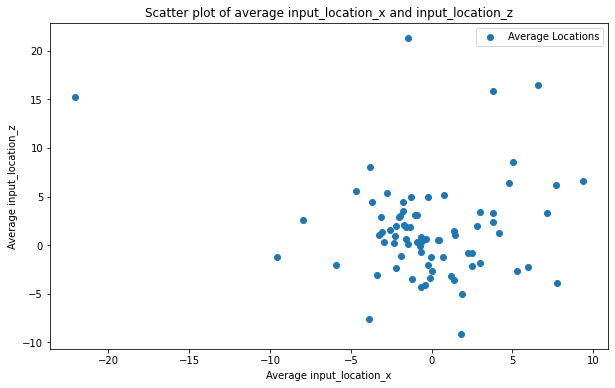

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Initialize lists to store averages
avg_input_location_x = []
avg_input_location_z = []

# Iterate over each DataFrame in new_dataframe
for key, df in new_dataframes.items():
    # Calculate average of 'input_location_x' and 'input_location_y'
    avg_input_location_x.append(np.mean(df['input_location_x']))
    avg_input_location_z.append(np.mean(df['input_location_z']))

# Convert lists to numpy arrays for plotting
avg_input_location_x = np.array(avg_input_location_x)
avg_input_location_z = np.array(avg_input_location_z)

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(avg_input_location_x, avg_input_location_z, label='Average Locations')
plt.xlabel('Average input_location_x')
plt.ylabel('Average input_location_z')
plt.title('Scatter plot of average input_location_x and input_location_z')
plt.legend()
plt.show()


/tmp/ipykernel_5394/3757103298.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  average_df = average_df.append(avg_df, ignore_index=True)
/tmp/ipykernel_5394/3757103298.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  average_df = average_df.append(avg_df, ignore_index=True)
/tmp/ipykernel_5394/3757103298.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  average_df = average_df.append(avg_df, ignore_index=True)
/tmp/ipykernel_5394/3757103298.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  average_df = average_df.append(avg_df, ignore_index=True)
/tmp/ipykernel_5394/3757103298.py:12: FutureWarning: The frame.append method

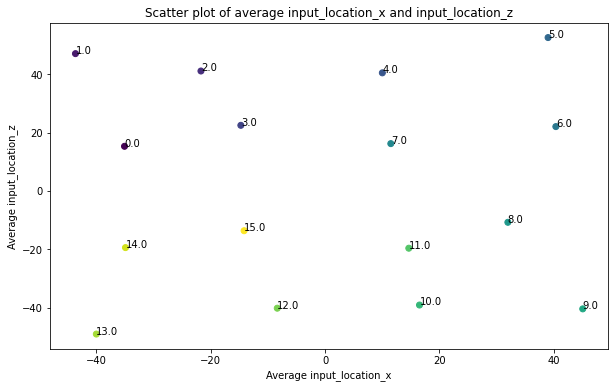

0      0.0
1      1.0
2      2.0
3      3.0
4      4.0
5      5.0
6      6.0
7      7.0
8      8.0
9      9.0
10    10.0
11    11.0
12    12.0
13    13.0
14    14.0
15    15.0
Name: object_loc, dtype: float64


In [100]:
import matplotlib.pyplot as plt
import pandas as pd

# Initialize an empty DataFrame to store averages
average_df = pd.DataFrame()

# Iterate over each DataFrame in new_dataframe
for key, df in new_dataframes.items():
    # Calculate average of 'input_location_x' and 'input_location_y' grouped by 'object_order'
    avg_df = df.groupby('object_loc')[['input_location_x', 'input_location_z']].mean().reset_index()
    # Append to average_df
    average_df = average_df.append(avg_df, ignore_index=True)

# Calculate the average across all dataframes
final_avg_df = average_df.groupby('object_loc')[['input_location_x', 'input_location_z']].mean().reset_index()

labels = final_avg_df['object_loc']

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(final_avg_df['input_location_x'], final_avg_df['input_location_z'], c=final_avg_df['object_loc'])
# Add labels to each point
for i, label in enumerate(labels):
    plt.text(final_avg_df['input_location_x'][i], final_avg_df['input_location_z'][i], label)
plt.xlabel('Average input_location_x')
plt.ylabel('Average input_location_z')
plt.title('Scatter plot of average input_location_x and input_location_z')
#plt.colorbar(label='object_num')
plt.show()

print(final_avg_df['object_loc'])


In [92]:
final_avg_df

,object_loc,input_location_x,input_location_z
0,0.0,-35.093193,15.323462
1,1.0,-43.673237,47.099771
2,2.0,-21.721487,41.140342
3,3.0,-14.742322,22.516442
4,4.0,10.010962,40.509860
5,5.0,39.002183,52.609635
6,6.0,40.361831,22.083327
7,7.0,11.491227,16.244515
8,8.0,31.968194,-10.734646
9,9.0,45.065776,-40.416657


# ACTUAL LOCATION BEFORE ROTATION IN FIRST BLOCK OF CODE (DONT RUN AGAIN AS IT WILL BE OVERWRITTEN TO MATCH THE AFTER ROTATION LOCATIONS

/tmp/ipykernel_5394/1180585380.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  average_actual_df = average_actual_df.append(avg_actual_df, ignore_index=True)
/tmp/ipykernel_5394/1180585380.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  average_actual_df = average_actual_df.append(avg_actual_df, ignore_index=True)
/tmp/ipykernel_5394/1180585380.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  average_actual_df = average_actual_df.append(avg_actual_df, ignore_index=True)
/tmp/ipykernel_5394/1180585380.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  average_actual_df = average_actual_df.append(avg_actual_df, ignore_inde

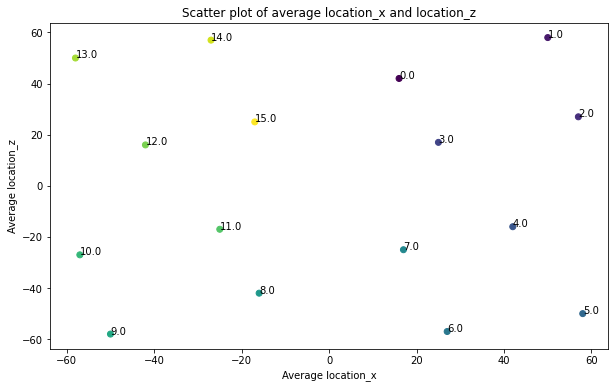

0      0.0
1      1.0
2      2.0
3      3.0
4      4.0
5      5.0
6      6.0
7      7.0
8      8.0
9      9.0
10    10.0
11    11.0
12    12.0
13    13.0
14    14.0
15    15.0
Name: object_loc, dtype: float64


In [94]:
import matplotlib.pyplot as plt
import pandas as pd

# Initialize an empty DataFrame to store averages
average_actual_df = pd.DataFrame()

# Iterate over each DataFrame in new_dataframe
for key, df in new_dataframes.items():
    # Calculate average of 'input_location_x' and 'input_location_y' grouped by 'object_order'
    avg_actual_df = df.groupby('object_loc')[['location_x', 'location_z']].mean().reset_index()
    # Append to average_df
    average_actual_df = average_actual_df.append(avg_actual_df, ignore_index=True)

# Calculate the average across all dataframes
final_avg_actual_df = average_actual_df.groupby('object_loc')[['location_x', 'location_z']].mean().reset_index()

labels = final_avg_actual_df['object_loc']

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(final_avg_actual_df['location_x'], final_avg_actual_df['location_z'], c=final_avg_actual_df['object_loc'])
# Add labels to each point
for i, label in enumerate(labels):
    plt.text(final_avg_actual_df['location_x'][i], final_avg_actual_df['location_z'][i], label)
plt.xlabel('Average location_x')
plt.ylabel('Average location_z')
plt.title('Scatter plot of average location_x and location_z')
#plt.colorbar(label='object_num')
plt.show()

print(final_avg_actual_df['object_loc'])


In [95]:
final_avg_actual_df

,object_loc,location_x,location_z
0,0.0,16.0,42.0
1,1.0,50.0,58.0
2,2.0,57.0,27.0
3,3.0,25.0,17.0
4,4.0,42.0,-16.0
5,5.0,58.0,-50.0
6,6.0,27.0,-57.0
7,7.0,17.0,-25.0
8,8.0,-16.0,-42.0
9,9.0,-50.0,-58.0


# ACTUAL LOCATION AFTER ROTATION IN FIRST BLOCK OF CODE

/tmp/ipykernel_5394/1180585380.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  average_actual_df = average_actual_df.append(avg_actual_df, ignore_index=True)
/tmp/ipykernel_5394/1180585380.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  average_actual_df = average_actual_df.append(avg_actual_df, ignore_index=True)
/tmp/ipykernel_5394/1180585380.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  average_actual_df = average_actual_df.append(avg_actual_df, ignore_index=True)
/tmp/ipykernel_5394/1180585380.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  average_actual_df = average_actual_df.append(avg_actual_df, ignore_inde

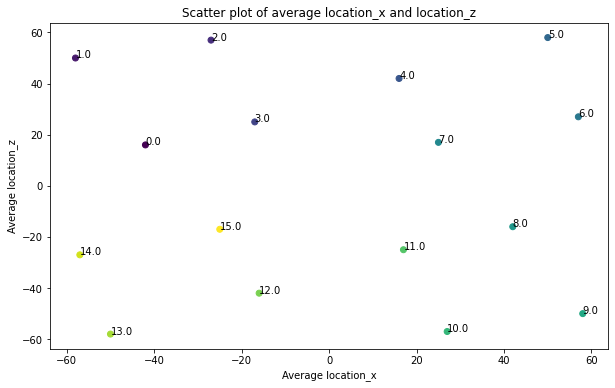

0      0.0
1      1.0
2      2.0
3      3.0
4      4.0
5      5.0
6      6.0
7      7.0
8      8.0
9      9.0
10    10.0
11    11.0
12    12.0
13    13.0
14    14.0
15    15.0
Name: object_loc, dtype: float64


In [101]:
import matplotlib.pyplot as plt
import pandas as pd

# Initialize an empty DataFrame to store averages
average_actual_df = pd.DataFrame()

# Iterate over each DataFrame in new_dataframe
for key, df in new_dataframes.items():
    # Calculate average of 'input_location_x' and 'input_location_y' grouped by 'object_order'
    avg_actual_df = df.groupby('object_loc')[['location_x', 'location_z']].mean().reset_index()
    # Append to average_df
    average_actual_df = average_actual_df.append(avg_actual_df, ignore_index=True)

# Calculate the average across all dataframes
final_avg_actual_df = average_actual_df.groupby('object_loc')[['location_x', 'location_z']].mean().reset_index()

labels = final_avg_actual_df['object_loc']

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(final_avg_actual_df['location_x'], final_avg_actual_df['location_z'], c=final_avg_actual_df['object_loc'])
# Add labels to each point
for i, label in enumerate(labels):
    plt.text(final_avg_actual_df['location_x'][i], final_avg_actual_df['location_z'][i], label)
plt.xlabel('Average location_x')
plt.ylabel('Average location_z')
plt.title('Scatter plot of average location_x and location_z')
#plt.colorbar(label='object_num')
plt.show()

print(final_avg_actual_df['object_loc'])


In [102]:
final_avg_actual_df

,object_loc,location_x,location_z
0,0.0,-42.0,16.0
1,1.0,-58.0,50.0
2,2.0,-27.0,57.0
3,3.0,-17.0,25.0
4,4.0,16.0,42.0
5,5.0,50.0,58.0
6,6.0,57.0,27.0
7,7.0,25.0,17.0
8,8.0,42.0,-16.0
9,9.0,58.0,-50.0


In [103]:
# Select the desired columns
#selected_columns = ['object_loc', 'group', 'time', 'location_x', 'location_z']

# Create the new DataFrame
#actual_loc_df = new_dataframes['102'][selected_columns]

# If you want to save this DataFrame to a CSV file, you can do so with the following line of code:
# new_df.to_csv('new_dataframe.csv', index=False)

actual_loc_df = new_dataframes['102'][['object_loc','location_x','location_z']]

In [104]:
actual_loc_df

,object_loc,location_x,location_z
0,1.0,-58.0,50.0
1,0.0,-42.0,16.0
2,10.0,27.0,-57.0
3,7.0,25.0,17.0
4,13.0,-50.0,-58.0
5,3.0,-17.0,25.0
6,15.0,-25.0,-17.0
7,5.0,50.0,58.0
8,2.0,-27.0,57.0
9,11.0,17.0,-25.0


In [105]:
merged_avg_df = pd.merge(final_avg_df, actual_loc_df, on='object_loc', how='outer')

In [106]:
merged_avg_df

,object_loc,input_location_x,input_location_z,location_x,location_z
0,0.0,-35.093193,15.323462,-42.0,16.0
1,1.0,-43.673237,47.099771,-58.0,50.0
2,2.0,-21.721487,41.140342,-27.0,57.0
3,3.0,-14.742322,22.516442,-17.0,25.0
4,4.0,10.010962,40.509860,16.0,42.0
5,5.0,39.002183,52.609635,50.0,58.0
6,6.0,40.361831,22.083327,57.0,27.0
7,7.0,11.491227,16.244515,25.0,17.0
8,8.0,31.968194,-10.734646,42.0,-16.0
9,9.0,45.065776,-40.416657,58.0,-50.0


In [107]:
import pandas as pd
from scipy.spatial import distance_matrix

# Function to create distance matrix
def create_dist_matrix(df, x_col, z_col):
    df = df.sort_values('object_loc')  # Sort the DataFrame   
    df['coordinates'] = list(zip(df[x_col], df[z_col]))
    dist_matrix = pd.DataFrame(
        distance_matrix(df['coordinates'].tolist(), df['coordinates'].tolist()),
        index=df['object_loc'],
        columns=df['object_loc']
    )
    return dist_matrix

# Create new dictionaries to store the distance matrices
#avg_input_dist_matrix = {}
#avg_actual_dist_matrix = {}
#avg_result_dist_matrix = {}

# Loop over each DataFrame in 'new_dataframes'
#for label, df in new_dataframes.items():
# Create 'input' distance matrix
avg_input_dist_matrix = create_dist_matrix(merged_avg_df, 'input_location_x', 'input_location_z')
#input_dist_matrices[label] = input_dist_matrix

# Create 'actual' distance matrix
avg_actual_dist_matrix = create_dist_matrix(merged_avg_df, 'location_x', 'location_z')
#actual_dist_matrices[label] = actual_dist_matrix

# Divide 'input' by 'actual' element-wise
avg_result_dist_matrix = input_dist_matrix / actual_dist_matrix
#result_dist_matrices[label] = result_dist_matrix



In [108]:
avg_result_dist_matrix

object_loc,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0
object_loc,,,,,,,,,,,,,,,,
0.0,NaN,1.729800,1.567559,1.986042,1.543914,1.225597,1.154276,1.146582,1.113421,0.893829,0.759817,0.836917,0.906090,0.804888,0.675371,0.424307
1.0,1.729800,NaN,0.718226,0.947003,1.256813,1.167285,1.097318,0.939672,1.192674,1.038450,1.012669,1.083333,1.210856,1.061968,1.107629,1.075515
2.0,1.567559,0.718226,NaN,0.891106,1.574624,1.358983,1.217222,0.986721,1.290887,1.088900,1.068103,1.158619,1.255712,1.065374,1.058365,1.106698
3.0,1.986042,0.947003,0.891106,NaN,1.437121,1.135702,1.137097,0.916277,1.389584,1.123102,1.162592,1.316209,1.554864,1.261325,1.263943,1.459635
4.0,1.543914,1.256813,1.574624,1.437121,NaN,0.876619,0.936376,0.863050,1.365849,1.125082,1.249103,1.385210,1.509788,1.299334,1.280771,1.415803
5.0,1.225597,1.167285,1.358983,1.135702,0.876619,NaN,0.686283,0.997377,1.102936,1.019612,1.135238,1.158031,1.270259,1.161997,1.122437,1.173064
6.0,1.154276,1.097318,1.217222,1.137097,0.936376,0.686283,NaN,1.342294,1.329190,1.153312,1.278957,1.307057,1.355959,1.208278,1.131978,1.213262
7.0,1.146582,0.939672,0.986721,0.916277,0.863050,0.997377,1.342294,NaN,1.961450,1.307704,1.390987,1.667179,1.570169,1.256544,1.149307,1.310913
8.0,1.113421,1.192674,1.290887,1.389584,1.365849,1.102936,1.329190,1.961450,NaN,0.754097,1.417458,1.684936,1.478497,1.298148,1.189182,1.343652


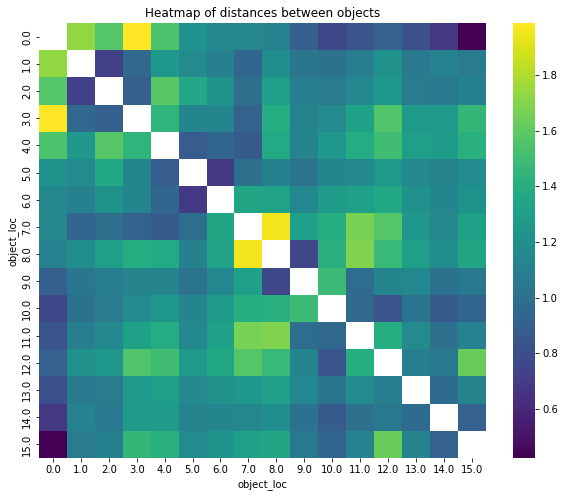

In [109]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming dist_matrix is your DataFrame
plt.figure(figsize=(10, 8))
sns.heatmap(avg_result_dist_matrix, cmap='viridis')
plt.title('Heatmap of distances between objects')
plt.show()


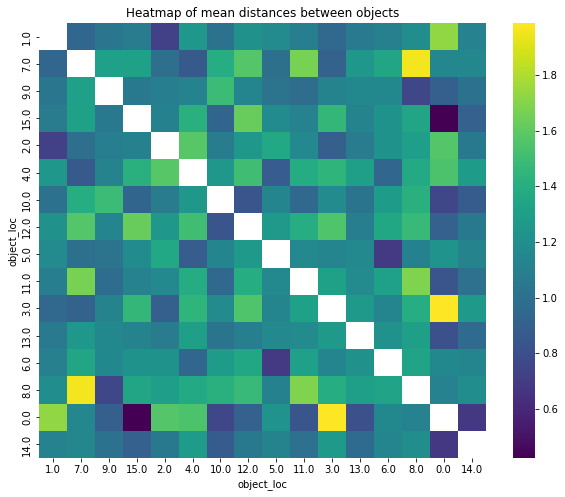

In [110]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the custom order
custom_order = [1,7,9,15,2,4,10,12,5,11,3,13,6,8,0,14]

# Reorder the DataFrame
avg_result_dist_matrix1 = avg_result_dist_matrix.loc[custom_order, custom_order]

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(avg_result_dist_matrix1, cmap='viridis')
plt.title('Heatmap of mean distances between objects')
plt.show()

In [111]:
avg_result_dist_matrix1

object_loc,1.0,7.0,9.0,15.0,2.0,4.0,10.0,12.0,5.0,11.0,3.0,13.0,6.0,8.0,0.0,14.0
object_loc,,,,,,,,,,,,,,,,
1.0,NaN,0.939672,1.038450,1.075515,0.718226,1.256813,1.012669,1.210856,1.167285,1.083333,0.947003,1.061968,1.097318,1.192674,1.729800,1.107629
7.0,0.939672,NaN,1.307704,1.310913,0.986721,0.863050,1.390987,1.570169,0.997377,1.667179,0.916277,1.256544,1.342294,1.961450,1.146582,1.149307
9.0,1.038450,1.307704,NaN,1.052789,1.088900,1.125082,1.488461,1.136286,1.019612,0.978056,1.123102,1.153019,1.153312,0.754097,0.893829,1.011857
15.0,1.075515,1.310913,1.052789,NaN,1.106698,1.415803,0.926703,1.624223,1.173064,1.110507,1.459635,1.124774,1.213262,1.343652,0.424307,0.901017
2.0,0.718226,0.986721,1.088900,1.106698,NaN,1.574624,1.068103,1.255712,1.358983,1.158619,0.891106,1.065374,1.217222,1.290887,1.567559,1.058365
4.0,1.256813,0.863050,1.125082,1.415803,1.574624,NaN,1.249103,1.509788,0.876619,1.385210,1.437121,1.299334,0.936376,1.365849,1.543914,1.280771
10.0,1.012669,1.390987,1.488461,0.926703,1.068103,1.249103,NaN,0.833836,1.135238,0.945273,1.162592,1.022999,1.278957,1.417458,0.759817,0.875349
12.0,1.210856,1.570169,1.136286,1.624223,1.255712,1.509788,0.833836,NaN,1.270259,1.392779,1.554864,1.086669,1.355959,1.478497,0.906090,1.055888
5.0,1.167285,0.997377,1.019612,1.173064,1.358983,0.876619,1.135238,1.270259,NaN,1.158031,1.135702,1.161997,0.686283,1.102936,1.225597,1.122437


In [20]:
# Check if the matrix is symmetrical
if np.array_equal(avg_result_dist_matrix1, mean1_df.T):
    print("The matrix is symmetrical.")
else:
    print("The matrix is not symmetrical.")

NameError: name 'mean1_df' is not defined

In [21]:
new_dataframes['102']

,object_order,input_location_x,input_location_z,object_loc,group,time,location_x,location_z,actual_distance_conseq_diff,input_distance_conseq_diff,distance,label
0,tree,-65.833320,65.833340,1.0,A,1,50.0,58.0,NaN,NaN,116.097886,different
1,cone,47.083320,-8.749994,0.0,C,2,16.0,42.0,37.576588,135.324947,59.512475,different
2,bell,14.166690,-68.333330,10.0,B,1,-57.0,-27.0,100.448992,68.071128,82.299100,different
3,book,27.500000,9.166662,7.0,A,1,17.0,-25.0,74.027022,78.638578,35.743682,same
4,snowman,-66.249970,-67.916650,13.0,D,2,-58.0,50.0,106.066017,121.370894,118.204900,different
5,statue,-20.416660,25.000010,3.0,D,2,25.0,17.0,89.319651,103.605975,46.115867,same
6,chest,-22.083320,-19.583330,15.0,A,1,-17.0,25.0,42.755117,44.614482,44.872190,different
7,lamp,69.166650,68.750000,5.0,D,2,58.0,-50.0,106.066017,127.001316,119.273872,different
8,motorcycle,-16.666670,67.916650,2.0,B,1,57.0,27.0,77.006493,85.837365,84.267138,different
9,umbrella,22.916650,-27.500000,11.0,D,2,-25.0,-17.0,93.059121,103.301386,49.053597,different


In [112]:
# Initialize lists to store averages
location_x = new_dataframes['102']['location_x']
location_z = new_dataframes['102']['location_z']

In [113]:
object_loc = new_dataframes['102']['object_loc']

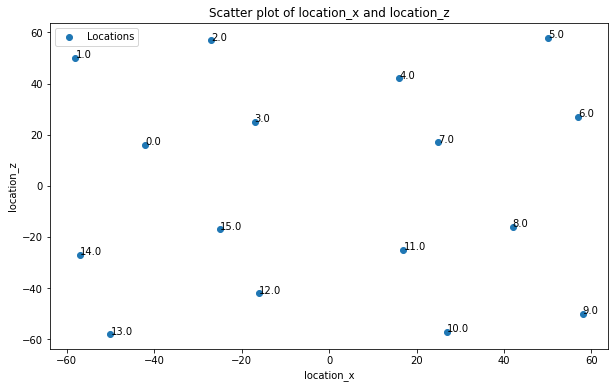

In [114]:
import matplotlib.pyplot as plt
import numpy as np

# Convert lists to numpy arrays for plotting
avg_input_location_x = np.array(location_x)
avg_input_location_z = np.array(location_z)

# Assuming labels is a list of labels for your data points
labels = object_loc

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(location_x, location_z, label='Locations')

# Add labels to each point
for i, label in enumerate(labels):
    plt.text(location_x[i], location_z[i], label)

plt.xlabel('location_x')
plt.ylabel('location_z')
plt.title('Scatter plot of location_x and location_z')
plt.legend()
plt.show()


In [115]:
import pandas as pd
import numpy as np

# Assuming df is your DataFrame and 'location_x' and 'location_y' are the columns
df = pd.DataFrame({
    'location_x': location_x,
    'location_z': location_z
})

# Rotate the coordinates
df['rotated_x'] = -df['location_z']
df['rotated_z'] = df['location_x']


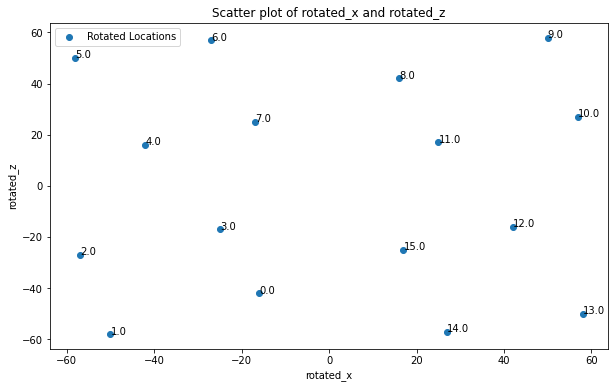

In [116]:
# # Plotting
# plt.figure(figsize=(10, 6))
# plt.scatter(location_x, location_z, label='Locations')

# # Add labels to each point
# for i, label in enumerate(labels):
#     plt.text(location_x[i], location_z[i], label)

# plt.xlabel('location_x')
# plt.ylabel('location_z')
# plt.title('Scatter plot of location_x and location_z')
# plt.legend()
# plt.show()

import matplotlib.pyplot as plt

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(df['rotated_x'], df['rotated_z'], label='Rotated Locations')

# Add labels to each point
for i, label in enumerate(labels):
    plt.text(df['rotated_x'][i], df['rotated_z'][i], label)

plt.xlabel('rotated_x')
plt.ylabel('rotated_z')
plt.title('Scatter plot of rotated_x and rotated_z')
plt.legend()
plt.show()


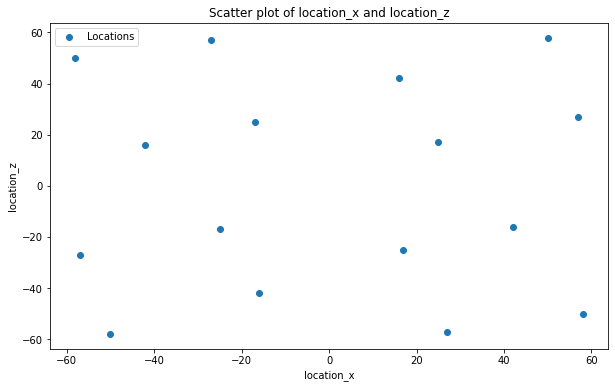

In [27]:
# Convert lists to numpy arrays for plotting
avg_input_location_x = np.array(location_x)
avg_input_location_z = np.array(location_z)

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(location_x, location_z, label='Locations')
plt.xlabel('location_x')
plt.ylabel('location_z')
plt.title('Scatter plot of location_x and location_z')
plt.legend()
plt.show()

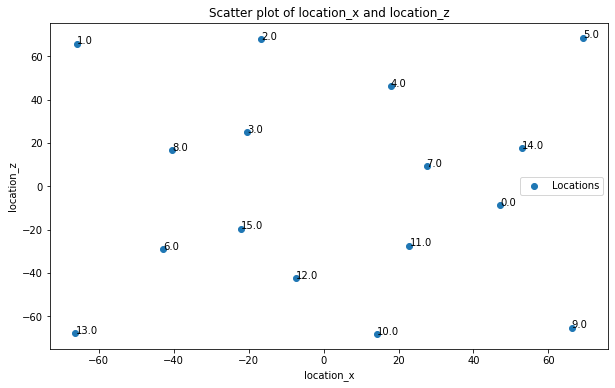

In [117]:
# Initialize lists to store averages
location_x = new_dataframes['102']['input_location_x']
location_z = new_dataframes['102']['input_location_z']
# Convert lists to numpy arrays for plotting
avg_input_location_x = np.array(location_x)
avg_input_location_z = np.array(location_z)

object_loc = new_dataframes['102']['object_loc']
# Assuming labels is a list of labels for your data points
labels = object_loc

# # Plotting
# plt.figure(figsize=(10, 6))
# plt.scatter(location_x, location_z, label='Locations')
# plt.xlabel('location_x')
# plt.ylabel('location_z')
# plt.title('Scatter plot of location_x and location_z')
# plt.legend()
# plt.show()

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(location_x, location_z, label='Locations')

# Add labels to each point
for i, label in enumerate(labels):
    plt.text(location_x[i], location_z[i], label)

plt.xlabel('location_x')
plt.ylabel('location_z')
plt.title('Scatter plot of location_x and location_z')
plt.legend()
plt.show()

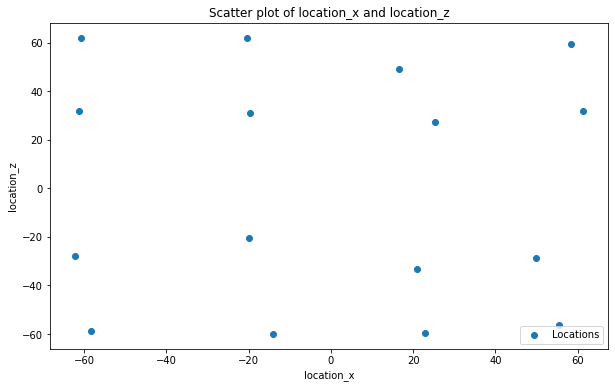

In [29]:
# Initialize lists to store averages
location_x = new_dataframes['103']['input_location_x']
location_z = new_dataframes['103']['input_location_z']
# Convert lists to numpy arrays for plotting
avg_input_location_x = np.array(location_x)
avg_input_location_z = np.array(location_z)

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(location_x, location_z, label='Locations')
plt.xlabel('location_x')
plt.ylabel('location_z')
plt.title('Scatter plot of location_x and location_z')
plt.legend()
plt.show()

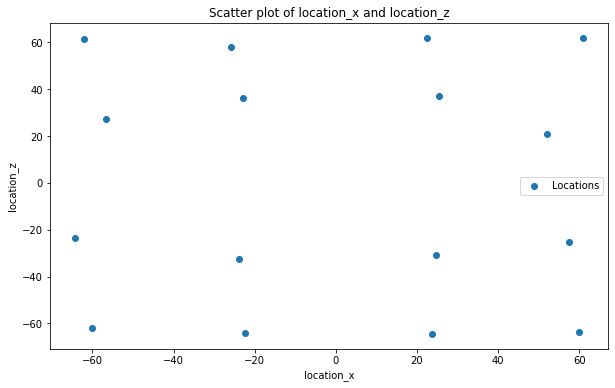

In [30]:
# Initialize lists to store averages
location_x = new_dataframes['104']['input_location_x']
location_z = new_dataframes['104']['input_location_z']
# Convert lists to numpy arrays for plotting
avg_input_location_x = np.array(location_x)
avg_input_location_z = np.array(location_z)

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(location_x, location_z, label='Locations')
plt.xlabel('location_x')
plt.ylabel('location_z')
plt.title('Scatter plot of location_x and location_z')
plt.legend()
plt.show()

In [118]:
import pandas as pd
from scipy.spatial import distance_matrix

# Assuming df2 is your DataFrame and it has columns 'input_location_x' and 'input_location_y'
new_df['coordinates'] = list(zip(new_df['input_location_x'], new_df['input_location_z']))

# Create the distance matrix
dist_matrix = pd.DataFrame(
    distance_matrix(new_df['coordinates'].tolist(), new_df['coordinates'].tolist()),
    index=new_df['object_loc'],
    columns=new_df['object_loc']
)


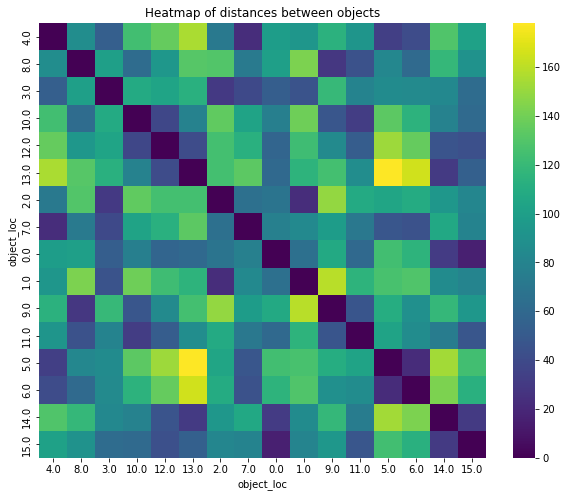

In [119]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming dist_matrix is your DataFrame
plt.figure(figsize=(10, 8))
sns.heatmap(dist_matrix, cmap='viridis')
plt.title('Heatmap of distances between objects')
plt.show()


# INPUT, ACTUAL AND INPUT/ACTUAL (RESULT) MATRIX CREATED

In [120]:
import pandas as pd
from scipy.spatial import distance_matrix

# Function to create distance matrix
def create_dist_matrix(df, x_col, z_col):
    df = df.sort_values('object_loc')  # Sort the DataFrame
    
    # Define the custom order
    #custom_order = [1,7,9,15,2,4,10,12,5,11,3,13,6,8,0,14]

    # Create a category type with the custom order
    #df['object_loc'] = df['object_loc'].astype('category')
    #df['object_loc'].cat.set_categories(custom_order, ordered=True, inplace=True)

    # Sort the DataFrame by 'object_loc'
    #df.sort_values('object_loc', inplace=True)

    
    df['coordinates'] = list(zip(df[x_col], df[z_col]))
    dist_matrix = pd.DataFrame(
        distance_matrix(df['coordinates'].tolist(), df['coordinates'].tolist()),
        index=df['object_loc'],
        columns=df['object_loc']
    )
    return dist_matrix

# Create new dictionaries to store the distance matrices
input_dist_matrices = {}
actual_dist_matrices = {}
result_dist_matrices = {}

# Loop over each DataFrame in 'new_dataframes'
for label, df in new_dataframes.items():
    # Create 'input' distance matrix
    input_dist_matrix = create_dist_matrix(df, 'input_location_x', 'input_location_z')
    input_dist_matrices[label] = input_dist_matrix
    
    # Create 'actual' distance matrix
    actual_dist_matrix = create_dist_matrix(df, 'location_x', 'location_z')
    actual_dist_matrices[label] = actual_dist_matrix
    
    # Divide 'input' by 'actual' element-wise
    result_dist_matrix = input_dist_matrix / actual_dist_matrix
    result_dist_matrices[label] = result_dist_matrix



In [121]:
result_dist_matrices['102']

object_loc,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0
object_loc,,,,,,,,,,,,,,,,
0.0,NaN,3.601310,2.283872,2.840248,0.979454,0.796816,0.926487,0.396115,1.013660,0.499266,0.677669,0.425730,1.009657,1.717668,0.590462,1.885970
1.0,3.601310,NaN,1.548458,1.271823,1.155552,1.246875,0.833280,1.222451,0.461937,1.215811,1.143095,1.214273,1.216611,1.235048,1.664918,1.284968
2.0,2.283872,1.548458,NaN,1.284974,0.896111,1.114677,1.127506,1.120344,0.562331,1.148988,1.107437,1.110062,1.112312,1.232974,0.963361,1.184263
3.0,2.840248,1.271823,1.284974,NaN,1.180701,1.334864,0.792331,1.180323,0.301567,1.180820,1.069584,1.125839,1.025628,1.159946,1.123634,1.043489
4.0,0.979454,1.155552,0.896111,1.180701,NaN,1.489531,2.219390,1.441500,1.029028,1.203142,1.150944,1.103150,1.027022,1.183794,0.450917,1.072175
5.0,0.796816,1.246875,1.114677,1.334864,1.489531,NaN,4.683058,1.514069,1.630108,1.239182,1.259451,1.195542,1.127629,1.256216,0.393439,1.197380
6.0,0.926487,0.833280,1.127506,0.792331,2.219390,4.683058,NaN,2.391404,1.007910,1.493743,0.776131,1.003803,0.376742,0.331005,0.845009,0.246422
7.0,0.396115,1.222451,1.120344,1.180323,1.441500,1.514069,2.391404,NaN,1.840703,1.125364,1.062296,0.864271,0.868588,1.144296,0.287429,0.947914
8.0,1.013660,0.461937,0.562331,0.301567,1.029028,1.630108,1.007910,1.840703,NaN,3.581847,2.313828,2.905938,1.065224,0.874490,0.937032,0.606236


In [122]:
result_dist_matrices['197']

object_loc,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0
object_loc,,,,,,,,,,,,,,,,
0.0,NaN,1.729800,1.567559,1.986042,1.543914,1.225597,1.154276,1.146582,1.113421,0.893829,0.759817,0.836917,0.906090,0.804888,0.675371,0.424307
1.0,1.729800,NaN,0.718226,0.947003,1.256813,1.167285,1.097318,0.939672,1.192674,1.038450,1.012669,1.083333,1.210856,1.061968,1.107629,1.075515
2.0,1.567559,0.718226,NaN,0.891106,1.574624,1.358983,1.217222,0.986721,1.290887,1.088900,1.068103,1.158619,1.255712,1.065374,1.058365,1.106698
3.0,1.986042,0.947003,0.891106,NaN,1.437121,1.135702,1.137097,0.916277,1.389584,1.123102,1.162592,1.316209,1.554864,1.261325,1.263943,1.459635
4.0,1.543914,1.256813,1.574624,1.437121,NaN,0.876619,0.936376,0.863050,1.365849,1.125082,1.249103,1.385210,1.509788,1.299334,1.280771,1.415803
5.0,1.225597,1.167285,1.358983,1.135702,0.876619,NaN,0.686283,0.997377,1.102936,1.019612,1.135238,1.158031,1.270259,1.161997,1.122437,1.173064
6.0,1.154276,1.097318,1.217222,1.137097,0.936376,0.686283,NaN,1.342294,1.329190,1.153312,1.278957,1.307057,1.355959,1.208278,1.131978,1.213262
7.0,1.146582,0.939672,0.986721,0.916277,0.863050,0.997377,1.342294,NaN,1.961450,1.307704,1.390987,1.667179,1.570169,1.256544,1.149307,1.310913
8.0,1.113421,1.192674,1.290887,1.389584,1.365849,1.102936,1.329190,1.961450,NaN,0.754097,1.417458,1.684936,1.478497,1.298148,1.189182,1.343652


In [123]:
result_dist_matrices

{'102': object_loc      0.0       1.0       2.0       3.0       4.0       5.0   \
 object_loc                                                               
 0.0              NaN  3.601310  2.283872  2.840248  0.979454  0.796816   
 1.0         3.601310       NaN  1.548458  1.271823  1.155552  1.246875   
 2.0         2.283872  1.548458       NaN  1.284974  0.896111  1.114677   
 3.0         2.840248  1.271823  1.284974       NaN  1.180701  1.334864   
 4.0         0.979454  1.155552  0.896111  1.180701       NaN  1.489531   
 5.0         0.796816  1.246875  1.114677  1.334864  1.489531       NaN   
 6.0         0.926487  0.833280  1.127506  0.792331  2.219390  4.683058   
 7.0         0.396115  1.222451  1.120344  1.180323  1.441500  1.514069   
 8.0         1.013660  0.461937  0.562331  0.301567  1.029028  1.630108   
 9.0         0.499266  1.215811  1.148988  1.180820  1.203142  1.239182   
 10.0        0.677669  1.143095  1.107437  1.069584  1.150944  1.259451   
 11.0        0.425

In [124]:
len(result_dist_matrices)

76

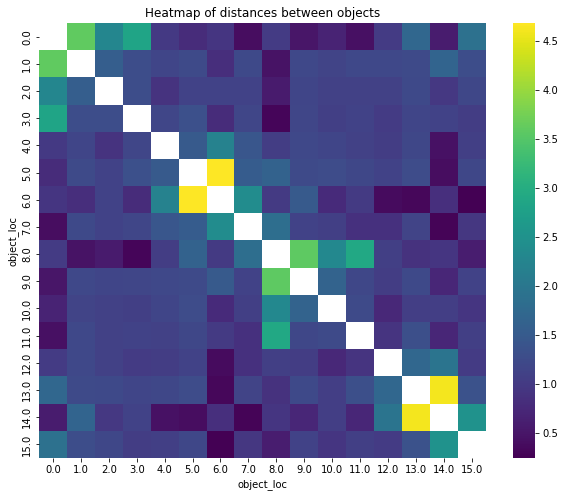

In [125]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming dist_matrix is your DataFrame
plt.figure(figsize=(10, 8))
sns.heatmap(result_dist_matrices['102'], cmap='viridis')
plt.title('Heatmap of distances between objects')
plt.show()

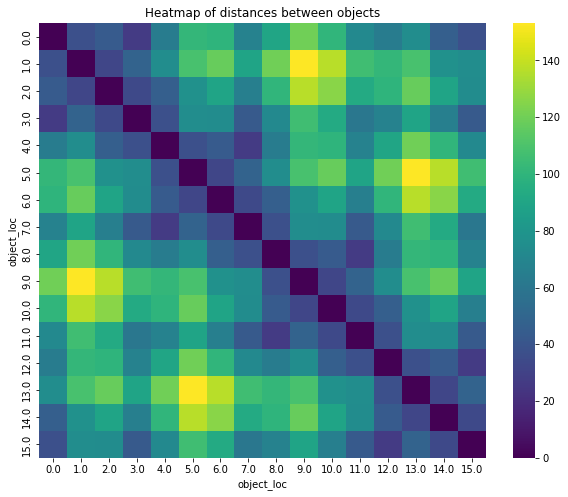

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming dist_matrix is your DataFrame
plt.figure(figsize=(10, 8))
sns.heatmap(actual_dist_matrices['102'], cmap='viridis')
plt.title('Heatmap of distances between objects')
plt.show()

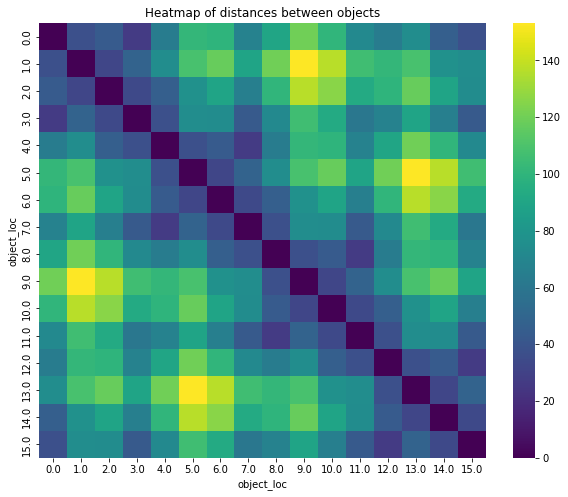

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming dist_matrix is your DataFrame
plt.figure(figsize=(10, 8))
sns.heatmap(actual_dist_matrices['103'], cmap='viridis')
plt.title('Heatmap of distances between objects')
plt.show()

In [45]:
actual_dist_matrices['103']

object_loc,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0
object_loc,,,,,,,,,,,,,,,,
0.0,0.000000,37.576588,43.657760,26.570661,63.560994,101.133575,99.609237,67.007462,89.888820,119.816526,100.448992,71.847060,63.560994,74.431176,45.541190,37.121422
1.0,37.576588,0.000000,31.780497,48.020829,74.431176,108.295891,117.277449,89.319651,119.816526,153.153518,136.652845,106.066017,101.133575,108.295891,77.006493,74.686009
2.0,43.657760,31.780497,0.000000,33.526109,45.541190,77.006493,89.196412,65.604878,100.448992,136.652845,126.142776,93.059121,99.609237,117.277449,89.196412,74.027022
3.0,26.570661,48.020829,33.526109,0.000000,37.121422,74.686009,74.027022,42.755117,71.847060,106.066017,93.059121,60.464866,67.007462,89.319651,65.604878,42.755117
4.0,63.560994,74.431176,45.541190,37.121422,0.000000,37.576588,43.657760,26.570661,63.560994,101.133575,99.609237,67.007462,89.888820,119.816526,100.448992,71.847060
5.0,101.133575,108.295891,77.006493,74.686009,37.576588,0.000000,31.780497,48.020829,74.431176,108.295891,117.277449,89.319651,119.816526,153.153518,136.652845,106.066017
6.0,99.609237,117.277449,89.196412,74.027022,43.657760,31.780497,0.000000,33.526109,45.541190,77.006493,89.196412,65.604878,100.448992,136.652845,126.142776,93.059121
7.0,67.007462,89.319651,65.604878,42.755117,26.570661,48.020829,33.526109,0.000000,37.121422,74.686009,74.027022,42.755117,71.847060,106.066017,93.059121,60.464866
8.0,89.888820,119.816526,100.448992,71.847060,63.560994,74.431176,45.541190,37.121422,0.000000,37.576588,43.657760,26.570661,63.560994,101.133575,99.609237,67.007462


In [46]:
# Replace diagonal NaNs with 0
#np.fill_diagonal(mean_df.values, 0)

In [47]:
mean_df

NameError: name 'mean_df' is not defined

In [132]:
mean_df #from order order below

,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0
0.0,NaN,1.596188,1.349697,1.693593,1.190464,1.150989,1.090550,1.059883,1.180804,1.012912,1.011498,1.174950,1.261789,1.185997,1.171583,1.536773
1.0,1.596188,NaN,1.621411,1.303694,1.112409,1.107654,0.970977,1.018583,1.024256,1.059539,0.984921,1.091775,1.191003,1.158835,1.223428,1.256774
2.0,1.349697,1.621411,NaN,1.280687,1.059940,1.128999,1.027661,1.016464,0.983665,0.984184,0.959304,1.001187,1.112904,1.039126,1.012540,1.101935
3.0,1.693593,1.303694,1.280687,NaN,1.337359,1.179546,1.047165,1.165430,1.085933,1.057118,0.968721,1.174693,1.245230,1.123431,1.106219,1.286985
4.0,1.190464,1.112409,1.059940,1.337359,NaN,1.455284,1.390330,1.609039,1.220092,1.110431,1.084425,1.211142,1.224886,1.093167,1.015496,1.155663
5.0,1.150989,1.107654,1.128999,1.179546,1.455284,NaN,1.711482,1.469950,1.155778,1.119047,1.049024,1.120274,1.100866,1.078826,1.007844,1.053477
6.0,1.090550,0.970977,1.027661,1.047165,1.390330,1.711482,NaN,1.532130,1.175734,1.193743,1.045386,1.101174,1.075470,0.985878,0.957232,0.963085
7.0,1.059883,1.018583,1.016464,1.165430,1.609039,1.469950,1.532130,NaN,1.505642,1.241523,1.102750,1.340054,1.158002,1.035876,0.934715,1.078369
8.0,1.180804,1.024256,0.983665,1.085933,1.220092,1.155778,1.175734,1.505642,NaN,1.618753,1.396907,1.668762,1.279919,1.115865,1.071283,1.098487
9.0,1.012912,1.059539,0.984184,1.057118,1.110431,1.119047,1.193743,1.241523,1.618753,NaN,1.554975,1.253786,1.108418,1.088436,1.006885,1.021186


In [135]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Create a master index that includes all unique 'object_loc' values from all DataFrames
master_index = pd.Index(np.unique([index for df in input_dist_matrices.values() for index in df.index]))

# Create a 3D numpy array of all reindexed DataFrames in 'result_dist_matrices'
all_dfs = np.array([df.reindex(master_index).values for df in input_dist_matrices.values()])

# Compute the mean across the third axis (depth), ignoring NaN values
mean_array = np.nanmean(all_dfs, axis=0)

# Convert the resulting numpy array back to a DataFrame
mean_input_df = pd.DataFrame(mean_array, index=master_index, columns=master_index)


In [136]:
mean_input_df

,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0
0.0,0.000000,59.979304,58.924752,44.999888,75.667048,116.403642,108.628884,71.020039,106.141123,121.363655,101.603928,84.416699,80.200549,88.275163,53.355293,57.047183
1.0,59.979304,0.000000,51.529240,62.604481,82.797875,119.954325,113.873758,90.979448,122.722815,162.272134,134.592227,115.800218,120.450357,125.497033,94.211876,93.863408
2.0,58.924752,51.529240,0.000000,42.936466,48.270942,86.940231,91.663656,66.685013,98.808202,134.491487,121.009281,93.169577,110.855485,121.866004,90.314954,81.572949
3.0,44.999888,62.604481,42.936466,0.000000,49.644675,88.095609,77.518542,49.828099,78.021107,112.124323,90.148366,71.027655,83.439734,100.344441,72.573357,55.025213
4.0,75.667048,82.797875,48.270942,49.644675,0.000000,54.684592,60.698714,42.753232,77.550260,112.301862,108.018716,81.155524,110.103601,130.979430,102.005513,83.030982
5.0,116.403642,119.954325,86.940231,88.095609,54.684592,0.000000,54.391756,70.588240,86.025929,121.188141,123.026807,100.062438,131.901960,165.225946,137.724707,111.738146
6.0,108.628884,113.873758,91.663656,77.518542,60.698714,54.391756,0.000000,51.366369,53.544339,91.925970,93.244664,72.242400,108.029885,134.723020,120.747843,89.623825
7.0,71.020039,90.979448,66.685013,49.828099,42.753232,70.588240,51.366369,0.000000,55.891554,92.724410,81.633334,57.294168,83.199067,109.871193,86.983711,65.203425
8.0,106.141123,122.722815,98.808202,78.021107,77.550260,86.025929,53.544339,55.891554,0.000000,60.827203,60.985810,44.340112,81.352908,112.851399,106.709657,73.606829
9.0,121.363655,162.272134,134.491487,112.124323,112.301862,121.188141,91.925970,92.724410,60.827203,0.000000,49.417880,60.207853,82.500831,117.873182,118.084930,91.212021


In [144]:
import numpy as np
import pandas as pd

# Assuming mean_input_df is your DataFrame
mean_input_df1 = mean_input_df.copy()
np.fill_diagonal(mean_input_df1.values, np.nan)


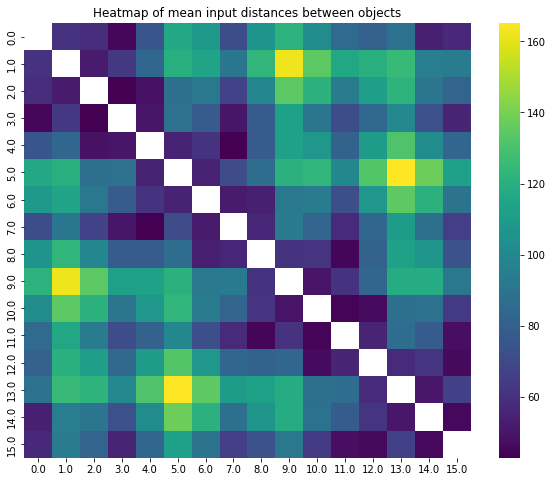

In [145]:
# Create a heatmap of the mean DataFrame
plt.figure(figsize=(10, 8))
sns.heatmap(mean_input_df1, cmap='viridis')
plt.title('Heatmap of mean input distances between objects')
# Save the figure
#plt.savefig("mapping_heatmap.svg", format='svg')
plt.show()

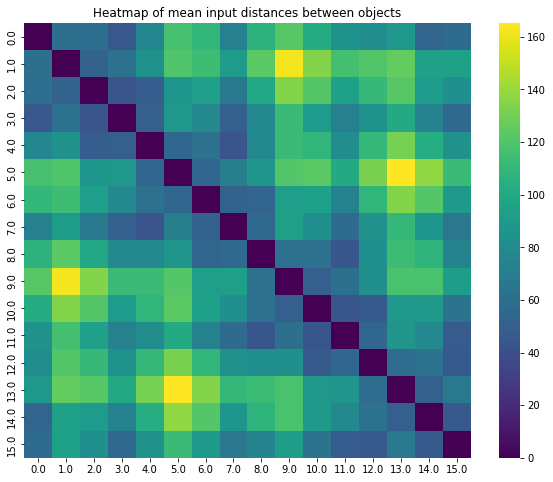

In [149]:
# Create a heatmap of the mean DataFrame
plt.figure(figsize=(10, 8))
sns.heatmap(mean_input_df, cmap='viridis')
plt.title('Heatmap of mean input distances between objects')
# Save the figure
#plt.savefig("mapping_heatmap.svg", format='svg')
plt.show()

In [152]:
mean_input_df

,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0
0.0,0.000000,59.979304,58.924752,44.999888,75.667048,116.403642,108.628884,71.020039,106.141123,121.363655,101.603928,84.416699,80.200549,88.275163,53.355293,57.047183
1.0,59.979304,0.000000,51.529240,62.604481,82.797875,119.954325,113.873758,90.979448,122.722815,162.272134,134.592227,115.800218,120.450357,125.497033,94.211876,93.863408
2.0,58.924752,51.529240,0.000000,42.936466,48.270942,86.940231,91.663656,66.685013,98.808202,134.491487,121.009281,93.169577,110.855485,121.866004,90.314954,81.572949
3.0,44.999888,62.604481,42.936466,0.000000,49.644675,88.095609,77.518542,49.828099,78.021107,112.124323,90.148366,71.027655,83.439734,100.344441,72.573357,55.025213
4.0,75.667048,82.797875,48.270942,49.644675,0.000000,54.684592,60.698714,42.753232,77.550260,112.301862,108.018716,81.155524,110.103601,130.979430,102.005513,83.030982
5.0,116.403642,119.954325,86.940231,88.095609,54.684592,0.000000,54.391756,70.588240,86.025929,121.188141,123.026807,100.062438,131.901960,165.225946,137.724707,111.738146
6.0,108.628884,113.873758,91.663656,77.518542,60.698714,54.391756,0.000000,51.366369,53.544339,91.925970,93.244664,72.242400,108.029885,134.723020,120.747843,89.623825
7.0,71.020039,90.979448,66.685013,49.828099,42.753232,70.588240,51.366369,0.000000,55.891554,92.724410,81.633334,57.294168,83.199067,109.871193,86.983711,65.203425
8.0,106.141123,122.722815,98.808202,78.021107,77.550260,86.025929,53.544339,55.891554,0.000000,60.827203,60.985810,44.340112,81.352908,112.851399,106.709657,73.606829
9.0,121.363655,162.272134,134.491487,112.124323,112.301862,121.188141,91.925970,92.724410,60.827203,0.000000,49.417880,60.207853,82.500831,117.873182,118.084930,91.212021


In [161]:
# Check if the matrix is symmetrical
if np.array_equal(mean_input_df, mean_input_df.T):
    print("The matrix is symmetrical.")
else:
    print("The matrix is not symmetrical.") # result1_df defined below

The matrix is symmetrical.


In [170]:
# Assuming mean_input_df is your DataFrame
mean_input_df.to_csv('mean_input_mapping_df.csv')


In [137]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Create a master index that includes all unique 'object_loc' values from all DataFrames
master_index = pd.Index(np.unique([index for df in actual_dist_matrices.values() for index in df.index]))

# Create a 3D numpy array of all reindexed DataFrames in 'result_dist_matrices'
all_dfs = np.array([df.reindex(master_index).values for df in actual_dist_matrices.values()])

# Compute the mean across the third axis (depth), ignoring NaN values
mean_array = np.nanmean(all_dfs, axis=0)

# Convert the resulting numpy array back to a DataFrame
mean_actual_df = pd.DataFrame(mean_array, index=master_index, columns=master_index)



In [138]:
mean_actual_df

,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0
0.0,0.000000,37.576588,43.657760,26.570661,63.560994,101.133575,99.609237,67.007462,89.888820,119.816526,100.448992,71.847060,63.560994,74.431176,45.541190,37.121422
1.0,37.576588,0.000000,31.780497,48.020829,74.431176,108.295891,117.277449,89.319651,119.816526,153.153518,136.652845,106.066017,101.133575,108.295891,77.006493,74.686009
2.0,43.657760,31.780497,0.000000,33.526109,45.541190,77.006493,89.196412,65.604878,100.448992,136.652845,126.142776,93.059121,99.609237,117.277449,89.196412,74.027022
3.0,26.570661,48.020829,33.526109,0.000000,37.121422,74.686009,74.027022,42.755117,71.847060,106.066017,93.059121,60.464866,67.007462,89.319651,65.604878,42.755117
4.0,63.560994,74.431176,45.541190,37.121422,0.000000,37.576588,43.657760,26.570661,63.560994,101.133575,99.609237,67.007462,89.888820,119.816526,100.448992,71.847060
5.0,101.133575,108.295891,77.006493,74.686009,37.576588,0.000000,31.780497,48.020829,74.431176,108.295891,117.277449,89.319651,119.816526,153.153518,136.652845,106.066017
6.0,99.609237,117.277449,89.196412,74.027022,43.657760,31.780497,0.000000,33.526109,45.541190,77.006493,89.196412,65.604878,100.448992,136.652845,126.142776,93.059121
7.0,67.007462,89.319651,65.604878,42.755117,26.570661,48.020829,33.526109,0.000000,37.121422,74.686009,74.027022,42.755117,71.847060,106.066017,93.059121,60.464866
8.0,89.888820,119.816526,100.448992,71.847060,63.560994,74.431176,45.541190,37.121422,0.000000,37.576588,43.657760,26.570661,63.560994,101.133575,99.609237,67.007462
9.0,119.816526,153.153518,136.652845,106.066017,101.133575,108.295891,77.006493,74.686009,37.576588,0.000000,31.780497,48.020829,74.431176,108.295891,117.277449,89.319651


In [140]:
actual_dist_matrices['103'] #confirmation from above

object_loc,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0
object_loc,,,,,,,,,,,,,,,,
0.0,0.000000,37.576588,43.657760,26.570661,63.560994,101.133575,99.609237,67.007462,89.888820,119.816526,100.448992,71.847060,63.560994,74.431176,45.541190,37.121422
1.0,37.576588,0.000000,31.780497,48.020829,74.431176,108.295891,117.277449,89.319651,119.816526,153.153518,136.652845,106.066017,101.133575,108.295891,77.006493,74.686009
2.0,43.657760,31.780497,0.000000,33.526109,45.541190,77.006493,89.196412,65.604878,100.448992,136.652845,126.142776,93.059121,99.609237,117.277449,89.196412,74.027022
3.0,26.570661,48.020829,33.526109,0.000000,37.121422,74.686009,74.027022,42.755117,71.847060,106.066017,93.059121,60.464866,67.007462,89.319651,65.604878,42.755117
4.0,63.560994,74.431176,45.541190,37.121422,0.000000,37.576588,43.657760,26.570661,63.560994,101.133575,99.609237,67.007462,89.888820,119.816526,100.448992,71.847060
5.0,101.133575,108.295891,77.006493,74.686009,37.576588,0.000000,31.780497,48.020829,74.431176,108.295891,117.277449,89.319651,119.816526,153.153518,136.652845,106.066017
6.0,99.609237,117.277449,89.196412,74.027022,43.657760,31.780497,0.000000,33.526109,45.541190,77.006493,89.196412,65.604878,100.448992,136.652845,126.142776,93.059121
7.0,67.007462,89.319651,65.604878,42.755117,26.570661,48.020829,33.526109,0.000000,37.121422,74.686009,74.027022,42.755117,71.847060,106.066017,93.059121,60.464866
8.0,89.888820,119.816526,100.448992,71.847060,63.560994,74.431176,45.541190,37.121422,0.000000,37.576588,43.657760,26.570661,63.560994,101.133575,99.609237,67.007462


In [146]:
import numpy as np
import pandas as pd

# Assuming mean_input_df is your DataFrame
mean_actual_df1 = mean_actual_df.copy()
np.fill_diagonal(mean_actual_df1.values, np.nan)

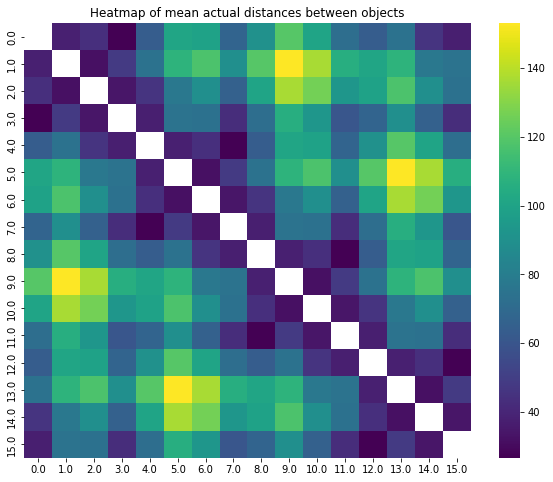

In [147]:
# Create a heatmap of the mean DataFrame
plt.figure(figsize=(10, 8))
sns.heatmap(mean_actual_df1, cmap='viridis')
plt.title('Heatmap of mean actual distances between objects')
# Save the figure
#plt.savefig("mapping_heatmap.svg", format='svg')
plt.show()

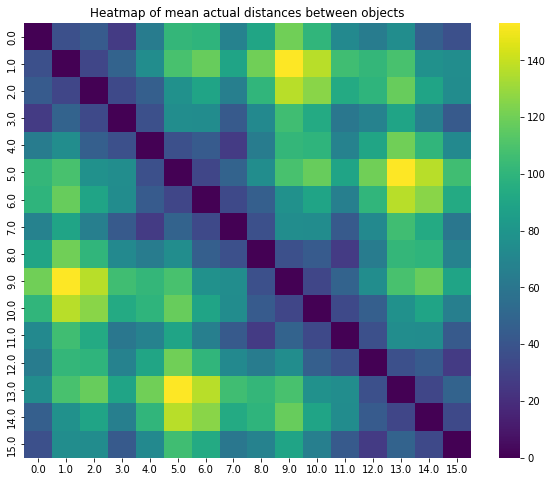

In [148]:
# Create a heatmap of the mean DataFrame
plt.figure(figsize=(10, 8))
sns.heatmap(mean_actual_df, cmap='viridis')
plt.title('Heatmap of mean actual distances between objects')
# Save the figure
#plt.savefig("mapping_heatmap.svg", format='svg')
plt.show()

In [162]:
# Check if the matrix is symmetrical
if np.array_equal(mean_actual_df, mean_actual_df.T):
    print("The matrix is symmetrical.")
else:
    print("The matrix is not symmetrical.") # result1_df defined below

The matrix is symmetrical.


In [171]:
# Assuming mean_input_df is your DataFrame
mean_actual_df.to_csv('mean_actual_mapping_df.csv')

In [172]:
mean_actual_test = mean_actual_df-actual_dist_matrices['103']
mean_actual_test
# Assuming mean_input_df is your DataFrame
mean_actual_test.to_csv('mean_actual_test.csv')

In [166]:

# Check if the matrix is symmetrical
if np.array_equal(mean_actual_df, actual_dist_matrices['103'].T):
    print("The matrix is symmetrical.")
else:
    print("The matrix is not symmetrical.") # result1_df defined below

The matrix is not symmetrical.


In [153]:
import pandas as pd

# Assuming mean_input_df and mean_actual_df are your DataFrames
# Flatten the DataFrames to 1D arrays
mean_input_array = mean_input_df.values.flatten()
mean_actual_array = mean_actual_df.values.flatten()

# Create Series from the arrays
mean_input_series = pd.Series(mean_input_array)
mean_actual_series = pd.Series(mean_actual_array)

# Compute correlation
correlation = mean_input_series.corr(mean_actual_series)

print(correlation)


0.9785304316248398


In [160]:
import numpy as np
import pandas as pd

# Assuming mean_input_df and mean_actual_df are your DataFrames
# Get the upper triangular indices
triu_indices = np.triu_indices(mean_input_df.shape[0], k=1)

# Extract the upper triangular parts of the matrices as 1D arrays
mean_input_array = mean_input_df.values[triu_indices]
mean_actual_array = mean_actual_df.values[triu_indices]

# Create Series from the arrays
mean_input_series = pd.Series(mean_input_array)
mean_actual_series = pd.Series(mean_actual_array)

# Compute correlation
correlation = mean_input_series.corr(mean_actual_series)

print(correlation)


0.9770481265192899


In [157]:
mean_input_array

array([ 59.97930382,  58.92475238,  44.99988798,  75.66704756,
       116.40364229, 108.62888437,  71.02003878, 106.14112275,
       121.36365539, 101.60392846,  84.41669914,  80.20054852,
        88.27516253,  53.35529291,  57.0471831 ,  51.52924001,
        62.60448108,  82.79787531, 119.95432548, 113.87375846,
        90.97944802, 122.72281499, 162.27213373, 134.59222743,
       115.80021837, 120.45035741, 125.49703258,  94.21187644,
        93.86340835,  42.93646561,  48.27094165,  86.9402306 ,
        91.66365567,  66.68501264,  98.80820158, 134.49148747,
       121.00928076,  93.169577  , 110.85548486, 121.86600429,
        90.31495408,  81.5729486 ,  49.64467515,  88.0956091 ,
        77.51854227,  49.82809945,  78.02110718, 112.12432342,
        90.1483663 ,  71.02765502,  83.43973397, 100.34444091,
        72.57335675,  55.02521339,  54.6845921 ,  60.69871365,
        42.75323153,  77.55025984, 112.30186242, 108.01871574,
        81.15552392, 110.10360102, 130.97942964, 102.00

In [164]:
import numpy as np
import pandas as pd

# Assuming mean_input_df and mean_actual_df are your DataFrames
# Get the lower triangular indices
tril_indices = np.tril_indices(mean_input_df.shape[0], k=-1)

# Extract the upper triangular parts of the matrices as 1D arrays
mean_input_array = mean_input_df.values[tril_indices]
mean_actual_array = mean_actual_df.values[tril_indices]

# Create Series from the arrays
mean_input_series = pd.Series(mean_input_array)
mean_actual_series = pd.Series(mean_actual_array)

# Compute correlation
correlation = mean_input_series.corr(mean_actual_series)

print(correlation)


0.9770481265192897


In [163]:
import numpy as np
import pandas as pd

# Assuming mean_input_df and mean_actual_df are your DataFrames
# Get the upper and lower triangular indices
triu_indices = np.triu_indices(mean_input_df.shape[0], k=1)
tril_indices = np.tril_indices(mean_input_df.shape[0], k=-1)

# Extract the upper and lower triangular parts of the matrices as 1D arrays
mean_input_array_upper = mean_input_df.values[triu_indices]
mean_actual_array_upper = mean_actual_df.values[triu_indices]

mean_input_array_lower = mean_input_df.values[tril_indices]
mean_actual_array_lower = mean_actual_df.values[tril_indices]

# Create Series from the arrays
mean_input_series_upper = pd.Series(mean_input_array_upper)
mean_actual_series_upper = pd.Series(mean_actual_array_upper)

mean_input_series_lower = pd.Series(mean_input_array_lower)
mean_actual_series_lower = pd.Series(mean_actual_array_lower)

# Compute correlation
correlation_upper = mean_input_series_upper.corr(mean_actual_series_upper)
correlation_lower = mean_input_series_lower.corr(mean_actual_series_lower)

print(f"Correlation (upper triangular): {correlation_upper}")
print(f"Correlation (lower triangular): {correlation_lower}")


Correlation (upper triangular): 0.9770481265192899
Correlation (lower triangular): 0.9770481265192897


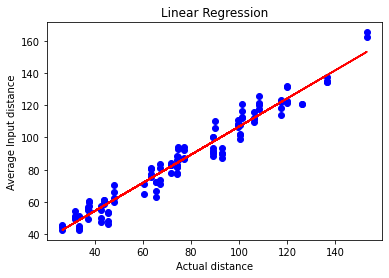

In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Assuming mean_df and actual_dist_matrices['103'] are pandas DataFrames
# Flatten the matrices and remove the diagonal elements
mean_df_values = mean_input_df.values[np.triu_indices(mean_df.shape[0], k=1)]
actual_df_values = actual_dist_matrices['103'].values[np.triu_indices(actual_dist_matrices['103'].shape[0], k=1)]

# Prepare the data for linear regression
y = mean_df_values  # Features
X = actual_df_values.reshape(-1, 1)  # Target variable

# Create a Linear Regression model
model = LinearRegression()

# Fit the model
model.fit(X, y)

# Make predictions
predictions = model.predict(X)

# Plot the results
plt.scatter(X, y, color='blue')
plt.plot(X, predictions, color='red')
plt.title('Linear Regression')
plt.xlabel('Actual distance')
plt.ylabel('Average Input distance')
#plt.savefig("InputVActual.svg", format='svg')
plt.show()


In [155]:
# Calculate the correlation
correlation = mean_input_df.corrwith(actual_dist_matrices['103'])

# Print the correlation
print(correlation)


0.0     0.976121
1.0     0.978415
2.0     0.985061
3.0     0.977636
4.0     0.984637
5.0     0.988013
6.0     0.978872
7.0     0.953913
8.0     0.974458
9.0     0.984442
10.0    0.983676
11.0    0.980306
12.0    0.981248
13.0    0.987875
14.0    0.981233
15.0    0.959256
dtype: float64


# by original order

/tmp/ipykernel_5394/4070347286.py:13: RuntimeWarning: Mean of empty slice
  mean_array = np.nanmean(all_dfs, axis=0)


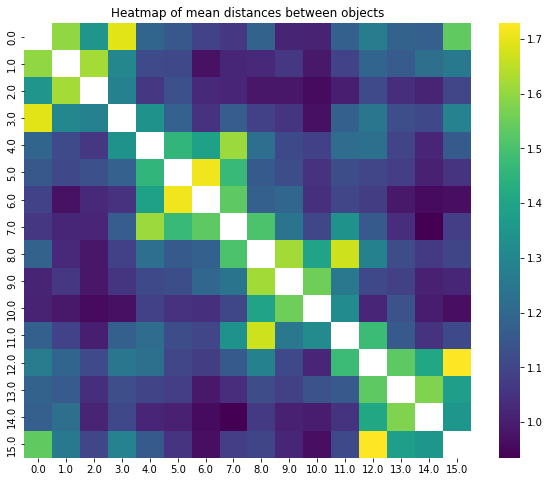

In [173]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Create a master index that includes all unique 'object_loc' values from all DataFrames
master_index = pd.Index(np.unique([index for df in result_dist_matrices.values() for index in df.index]))

# Create a 3D numpy array of all reindexed DataFrames in 'result_dist_matrices'
all_dfs = np.array([df.reindex(master_index).values for df in result_dist_matrices.values()])

# Compute the mean across the third axis (depth), ignoring NaN values
mean_array = np.nanmean(all_dfs, axis=0)

# Convert the resulting numpy array back to a DataFrame
mean_df = pd.DataFrame(mean_array, index=master_index, columns=master_index)

# Create a heatmap of the mean DataFrame
plt.figure(figsize=(10, 8))
sns.heatmap(mean_df, cmap='viridis')
plt.title('Heatmap of mean distances between objects')
# Save the figure
#plt.savefig("mapping_heatmap.svg", format='svg')
plt.show()


In [131]:
mean_df

,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0
0.0,NaN,1.596188,1.349697,1.693593,1.190464,1.150989,1.090550,1.059883,1.180804,1.012912,1.011498,1.174950,1.261789,1.185997,1.171583,1.536773
1.0,1.596188,NaN,1.621411,1.303694,1.112409,1.107654,0.970977,1.018583,1.024256,1.059539,0.984921,1.091775,1.191003,1.158835,1.223428,1.256774
2.0,1.349697,1.621411,NaN,1.280687,1.059940,1.128999,1.027661,1.016464,0.983665,0.984184,0.959304,1.001187,1.112904,1.039126,1.012540,1.101935
3.0,1.693593,1.303694,1.280687,NaN,1.337359,1.179546,1.047165,1.165430,1.085933,1.057118,0.968721,1.174693,1.245230,1.123431,1.106219,1.286985
4.0,1.190464,1.112409,1.059940,1.337359,NaN,1.455284,1.390330,1.609039,1.220092,1.110431,1.084425,1.211142,1.224886,1.093167,1.015496,1.155663
5.0,1.150989,1.107654,1.128999,1.179546,1.455284,NaN,1.711482,1.469950,1.155778,1.119047,1.049024,1.120274,1.100866,1.078826,1.007844,1.053477
6.0,1.090550,0.970977,1.027661,1.047165,1.390330,1.711482,NaN,1.532130,1.175734,1.193743,1.045386,1.101174,1.075470,0.985878,0.957232,0.963085
7.0,1.059883,1.018583,1.016464,1.165430,1.609039,1.469950,1.532130,NaN,1.505642,1.241523,1.102750,1.340054,1.158002,1.035876,0.934715,1.078369
8.0,1.180804,1.024256,0.983665,1.085933,1.220092,1.155778,1.175734,1.505642,NaN,1.618753,1.396907,1.668762,1.279919,1.115865,1.071283,1.098487
9.0,1.012912,1.059539,0.984184,1.057118,1.110431,1.119047,1.193743,1.241523,1.618753,NaN,1.554975,1.253786,1.108418,1.088436,1.006885,1.021186


In [174]:
# Assuming mean_input_df is your DataFrame
mean_df.to_csv('mean_df.csv')

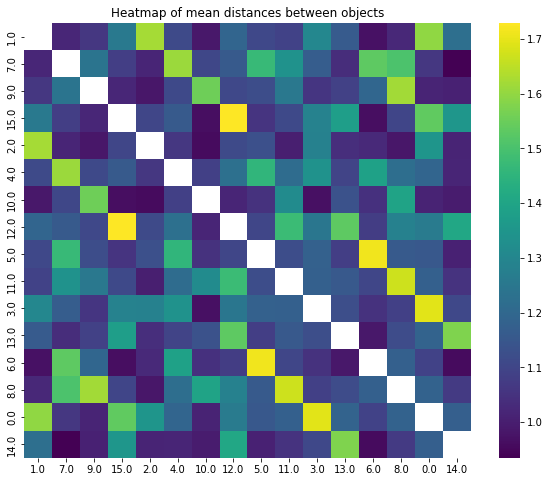

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the custom order
custom_order = [1,7,9,15,2,4,10,12,5,11,3,13,6,8,0,14]

# Reorder the DataFrame
mean1_df = mean_df.loc[custom_order, custom_order]

# # Create the heatmap
# plt.figure(figsize=(10, 8))
# sns.heatmap(result1_df, cmap='viridis')
# plt.title('Heatmap of mean distances between objects')
# # Save the figure
# plt.savefig("mapping_heatmap.svg", format='svg')
# plt.show()

# Create a mask for NaN values
mask = np.isnan(mean1_df)

plt.figure(figsize=(10, 8))
# Pass the mask to sns.heatmap
sns.heatmap(mean1_df, mask=mask, cmap='viridis')
plt.title('Heatmap of mean distances between objects')

# Save the figure
plt.savefig("mapping_heatmap_group_order.svg", format='svg')

plt.show()

In [56]:
mean1_df

,1.0,7.0,9.0,15.0,2.0,4.0,10.0,12.0,5.0,11.0,3.0,13.0,6.0,8.0,0.0,14.0
1.0,NaN,1.018583,1.059539,1.256774,1.621411,1.112409,0.984921,1.191003,1.107654,1.091775,1.303694,1.158835,0.970977,1.024256,1.596188,1.223428
7.0,1.018583,NaN,1.241523,1.078369,1.016464,1.609039,1.102750,1.158002,1.469950,1.340054,1.165430,1.035876,1.532130,1.505642,1.059883,0.934715
9.0,1.059539,1.241523,NaN,1.021186,0.984184,1.110431,1.554975,1.108418,1.119047,1.253786,1.057118,1.088436,1.193743,1.618753,1.012912,1.006885
15.0,1.256774,1.078369,1.021186,NaN,1.101935,1.155663,0.963502,1.729492,1.053477,1.110778,1.286985,1.377138,0.963085,1.098487,1.536773,1.352136
2.0,1.621411,1.016464,0.984184,1.101935,NaN,1.059940,0.959304,1.112904,1.128999,1.001187,1.280687,1.039126,1.027661,0.983665,1.349697,1.012540
4.0,1.112409,1.609039,1.110431,1.155663,1.059940,NaN,1.084425,1.224886,1.455284,1.211142,1.337359,1.093167,1.390330,1.220092,1.190464,1.015496
10.0,0.984921,1.102750,1.554975,0.963502,0.959304,1.084425,NaN,1.016168,1.049024,1.314785,0.968721,1.135236,1.045386,1.396907,1.011498,0.995160
12.0,1.191003,1.158002,1.108418,1.729492,1.112904,1.224886,1.016168,NaN,1.100866,1.476135,1.245230,1.531570,1.075470,1.279919,1.261789,1.409668
5.0,1.107654,1.469950,1.119047,1.053477,1.128999,1.455284,1.049024,1.100866,NaN,1.120274,1.179546,1.078826,1.711482,1.155778,1.150989,1.007844
11.0,1.091775,1.340054,1.253786,1.110778,1.001187,1.211142,1.314785,1.476135,1.120274,NaN,1.174693,1.155065,1.101174,1.668762,1.174950,1.050962


In [57]:
mean2_df = mean1_df.fillna(0)


In [65]:
# Check if the matrix is symmetrical
if np.array_equal(mean2_df, result1_df.T):
    print("The matrix is symmetrical.")
else:
    print("The matrix is not symmetrical.") # result1_df defined below

The matrix is symmetrical.


In [59]:
import pandas as pd
import numpy as np

# Create a master index that includes all unique 'object_loc' values from all DataFrames
master_index = pd.Index(np.unique([index for df in result_dist_matrices.values() for index in df.index]))

# Create a 3D numpy array of all reindexed DataFrames in 'result_dist_matrices'
all_dfs = np.array([df.reindex(master_index).values for df in result_dist_matrices.values()])

# Compute the sum across the third axis (depth), ignoring NaN values
sum_array = np.nansum(all_dfs, axis=0)

# Divide by 76
result_array = sum_array / 76

# Convert the resulting numpy array back to a DataFrame
result_df = pd.DataFrame(result_array, index=master_index, columns=master_index)


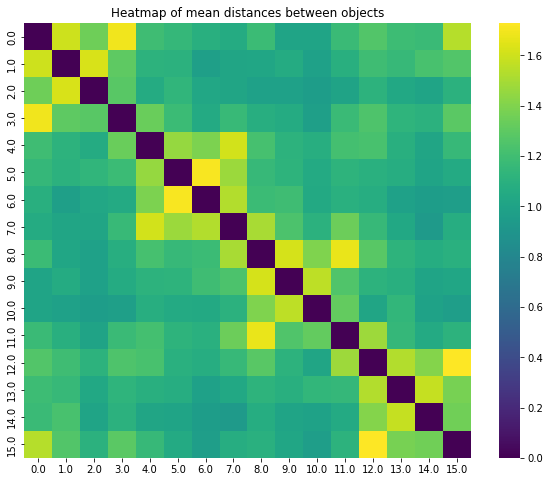

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming result_df is your DataFrame
plt.figure(figsize=(10, 8))
sns.heatmap(result_df, cmap='viridis')
plt.title('Heatmap of mean distances between objects')
plt.show()


In [61]:
result_df

,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0
0.0,0.000000,1.596188,1.349697,1.693593,1.190464,1.150989,1.090550,1.059883,1.180804,1.012912,1.011498,1.174950,1.261789,1.185997,1.171583,1.536773
1.0,1.596188,0.000000,1.621411,1.303694,1.112409,1.107654,0.970977,1.018583,1.024256,1.059539,0.984921,1.091775,1.191003,1.158835,1.223428,1.256774
2.0,1.349697,1.621411,0.000000,1.280687,1.059940,1.128999,1.027661,1.016464,0.983665,0.984184,0.959304,1.001187,1.112904,1.039126,1.012540,1.101935
3.0,1.693593,1.303694,1.280687,0.000000,1.337359,1.179546,1.047165,1.165430,1.085933,1.057118,0.968721,1.174693,1.245230,1.123431,1.106219,1.286985
4.0,1.190464,1.112409,1.059940,1.337359,0.000000,1.455284,1.390330,1.609039,1.220092,1.110431,1.084425,1.211142,1.224886,1.093167,1.015496,1.155663
5.0,1.150989,1.107654,1.128999,1.179546,1.455284,0.000000,1.711482,1.469950,1.155778,1.119047,1.049024,1.120274,1.100866,1.078826,1.007844,1.053477
6.0,1.090550,0.970977,1.027661,1.047165,1.390330,1.711482,0.000000,1.532130,1.175734,1.193743,1.045386,1.101174,1.075470,0.985878,0.957232,0.963085
7.0,1.059883,1.018583,1.016464,1.165430,1.609039,1.469950,1.532130,0.000000,1.505642,1.241523,1.102750,1.340054,1.158002,1.035876,0.934715,1.078369
8.0,1.180804,1.024256,0.983665,1.085933,1.220092,1.155778,1.175734,1.505642,0.000000,1.618753,1.396907,1.668762,1.279919,1.115865,1.071283,1.098487
9.0,1.012912,1.059539,0.984184,1.057118,1.110431,1.119047,1.193743,1.241523,1.618753,0.000000,1.554975,1.253786,1.108418,1.088436,1.006885,1.021186


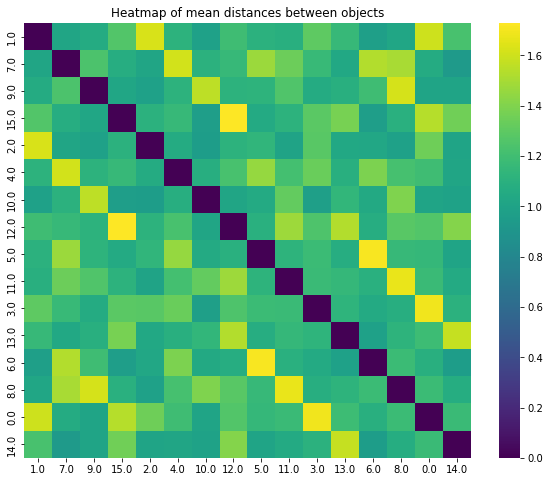

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the custom order
custom_order = [1,7,9,15,2,4,10,12,5,11,3,13,6,8,0,14]

# Reorder the DataFrame
result1_df = result_df.loc[custom_order, custom_order]

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(result1_df, cmap='viridis')
plt.title('Heatmap of mean distances between objects')
plt.show()


In [63]:
result1_df

,1.0,7.0,9.0,15.0,2.0,4.0,10.0,12.0,5.0,11.0,3.0,13.0,6.0,8.0,0.0,14.0
1.0,0.000000,1.018583,1.059539,1.256774,1.621411,1.112409,0.984921,1.191003,1.107654,1.091775,1.303694,1.158835,0.970977,1.024256,1.596188,1.223428
7.0,1.018583,0.000000,1.241523,1.078369,1.016464,1.609039,1.102750,1.158002,1.469950,1.340054,1.165430,1.035876,1.532130,1.505642,1.059883,0.934715
9.0,1.059539,1.241523,0.000000,1.021186,0.984184,1.110431,1.554975,1.108418,1.119047,1.253786,1.057118,1.088436,1.193743,1.618753,1.012912,1.006885
15.0,1.256774,1.078369,1.021186,0.000000,1.101935,1.155663,0.963502,1.729492,1.053477,1.110778,1.286985,1.377138,0.963085,1.098487,1.536773,1.352136
2.0,1.621411,1.016464,0.984184,1.101935,0.000000,1.059940,0.959304,1.112904,1.128999,1.001187,1.280687,1.039126,1.027661,0.983665,1.349697,1.012540
4.0,1.112409,1.609039,1.110431,1.155663,1.059940,0.000000,1.084425,1.224886,1.455284,1.211142,1.337359,1.093167,1.390330,1.220092,1.190464,1.015496
10.0,0.984921,1.102750,1.554975,0.963502,0.959304,1.084425,0.000000,1.016168,1.049024,1.314785,0.968721,1.135236,1.045386,1.396907,1.011498,0.995160
12.0,1.191003,1.158002,1.108418,1.729492,1.112904,1.224886,1.016168,0.000000,1.100866,1.476135,1.245230,1.531570,1.075470,1.279919,1.261789,1.409668
5.0,1.107654,1.469950,1.119047,1.053477,1.128999,1.455284,1.049024,1.100866,0.000000,1.120274,1.179546,1.078826,1.711482,1.155778,1.150989,1.007844
11.0,1.091775,1.340054,1.253786,1.110778,1.001187,1.211142,1.314785,1.476135,1.120274,0.000000,1.174693,1.155065,1.101174,1.668762,1.174950,1.050962


In [66]:
# Check if the matrix is symmetrical
if np.array_equal(result1_df, result1_df.T):
    print("The matrix is symmetrical.")
else:
    print("The matrix is not symmetrical.")

The matrix is symmetrical.


In [67]:
import numpy as np

# Assuming 'result1_df' is your DataFrame
matrix = result1_df.values

# Divide the matrix into four quadrants
q1 = matrix[:8, :8]
q2 = matrix[:8, 8:]
q3 = matrix[8:, :8]
q4 = matrix[8:, 8:]

# Find the sum of each quadrant
sum_q1 = np.sum(q1)
sum_q2 = np.sum(q2)
sum_q3 = np.sum(q3)
sum_q4 = np.sum(q4)

print(f"Sum of Quadrant 1: {sum_q1}")
print(f"Sum of Quadrant 2: {sum_q2}")
print(f"Sum of Quadrant 3: {sum_q3}")
print(f"Sum of Quadrant 4: {sum_q4}")


Sum of Quadrant 1: 65.27639729282251
Sum of Quadrant 2: 76.68428324033087
Sum of Quadrant 3: 76.68428324033088
Sum of Quadrant 4: 66.59737939572969


In [68]:
q1

array([[0.        , 1.01858267, 1.05953906, 1.25677365, 1.62141076,
        1.11240853, 0.98492079, 1.19100267],
       [1.01858267, 0.        , 1.24152316, 1.07836881, 1.01646424,
        1.60903909, 1.10275048, 1.15800239],
       [1.05953906, 1.24152316, 0.        , 1.02118649, 0.98418359,
        1.11043105, 1.55497504, 1.10841767],
       [1.25677365, 1.07836881, 1.02118649, 0.        , 1.10193476,
        1.15566291, 0.9635017 , 1.72949224],
       [1.62141076, 1.01646424, 0.98418359, 1.10193476, 0.        ,
        1.05994028, 0.95930409, 1.11290367],
       [1.11240853, 1.60903909, 1.11043105, 1.15566291, 1.05994028,
        0.        , 1.08442469, 1.22488648],
       [0.98492079, 1.10275048, 1.55497504, 0.9635017 , 0.95930409,
        1.08442469, 0.        , 1.0161677 ],
       [1.19100267, 1.15800239, 1.10841767, 1.72949224, 1.11290367,
        1.22488648, 1.0161677 , 0.        ]])

In [69]:
q2

array([[1.10765353, 1.09177493, 1.30369431, 1.15883467, 0.97097745,
        1.02425616, 1.59618811, 1.22342769],
       [1.46995048, 1.34005408, 1.16543009, 1.03587554, 1.53213035,
        1.5056415 , 1.05988253, 0.93471452],
       [1.11904653, 1.25378622, 1.05711826, 1.08843633, 1.1937431 ,
        1.61875268, 1.01291248, 1.00688522],
       [1.05347734, 1.11077777, 1.28698546, 1.37713785, 0.9630848 ,
        1.09848704, 1.53677255, 1.35213639],
       [1.1289987 , 1.00118694, 1.2806874 , 1.03912564, 1.02766079,
        0.98366544, 1.34969711, 1.01254021],
       [1.45528358, 1.21114158, 1.33735918, 1.09316664, 1.39033047,
        1.22009199, 1.19046356, 1.01549564],
       [1.04902356, 1.31478498, 0.96872145, 1.13523586, 1.04538581,
        1.39690654, 1.01149774, 0.99516015],
       [1.10086616, 1.47613492, 1.24523047, 1.53156966, 1.07547008,
        1.27991875, 1.26178876, 1.40966751]])

In [70]:
q3

array([[1.10765353, 1.46995048, 1.11904653, 1.05347734, 1.1289987 ,
        1.45528358, 1.04902356, 1.10086616],
       [1.09177493, 1.34005408, 1.25378622, 1.11077777, 1.00118694,
        1.21114158, 1.31478498, 1.47613492],
       [1.30369431, 1.16543009, 1.05711826, 1.28698546, 1.2806874 ,
        1.33735918, 0.96872145, 1.24523047],
       [1.15883467, 1.03587554, 1.08843633, 1.37713785, 1.03912564,
        1.09316664, 1.13523586, 1.53156966],
       [0.97097745, 1.53213035, 1.1937431 , 0.9630848 , 1.02766079,
        1.39033047, 1.04538581, 1.07547008],
       [1.02425616, 1.5056415 , 1.61875268, 1.09848704, 0.98366544,
        1.22009199, 1.39690654, 1.27991875],
       [1.59618811, 1.05988253, 1.01291248, 1.53677255, 1.34969711,
        1.19046356, 1.01149774, 1.26178876],
       [1.22342769, 0.93471452, 1.00688522, 1.35213639, 1.01254021,
        1.01549564, 0.99516015, 1.40966751]])

In [71]:
same_time = (sum_q1+sum_q4)/112
diff_time = (sum_q2+sum_q3)/128
all_time = (sum_q1+sum_q3+sum_q2+sum_q4)/240
print(same_time, diff_time, all_time)

1.1774444347192161 1.1981919256301699 1.188509763205058


#### Actual distance grouped by time

In [72]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist, squareform

# Define a function to calculate average distance
def average_distance(df):
    coordinates = df[['location_x', 'location_z']].values
    distances = squareform(pdist(coordinates))
    print('Distances:', distances)
    print('Number of values in distances:', np.size(distances))
    sum_distances = np.sum(distances)
    return sum_distances / 56

# Group the DataFrame by 'time' and apply the function
#average_distances = df.groupby('time').apply(average_distance)

# Create an empty dictionary to store the mean data frames
mean_dataframes_actual_time = {}

# Loop through the keys and values in the new_dataframes dictionary
for key, value in new_dataframes.items():
    
    # Group the DataFrame by 'time' and apply the function
    average_distances = value.groupby('time').apply(average_distance)
    mean_dataframes_actual_time[key] = average_distances
#     # Create a new data frame that groups the value data frame by the 'label' column
#     grouped_df = value.groupby('group_label')
#     # Create a new data frame that calculates the mean of 'distance' for each group
#     mean_df = grouped_df['key_resp.rt'].mean()
#     # Store the mean data frame in the dictionary with the key as the key
#     mean_dataframes[key] = mean_df
    

# Print the number of mean data frames created
print(f"Created {len(mean_dataframes_actual_time)} mean data frames.")


Distances: [[  0.         136.65284483  89.31965069  74.6860094   31.78049716
   74.43117626 153.15351775 101.13357504]
 [136.65284483   0.          74.02702209  65.60487787 126.14277625
   99.60923652  31.78049716  45.54119015]
 [ 89.31965069  74.02702209   0.          60.46486583  65.60487787
   26.57066051  74.6860094   71.84705979]
 [ 74.6860094   65.60487787  60.46486583   0.          74.02702209
   71.84705979  89.31965069  26.57066051]
 [ 31.78049716 126.14277625  65.60487787  74.02702209   0.
   45.54119015 136.65284483  99.60923652]
 [ 74.43117626  99.60923652  26.57066051  71.84705979  45.54119015
    0.         101.13357504  89.88882022]
 [153.15351775  31.78049716  74.6860094   89.31965069 136.65284483
  101.13357504   0.          74.43117626]
 [101.13357504  45.54119015  71.84705979  26.57066051  99.60923652
   89.88882022  74.43117626   0.        ]]
Number of values in distances: 64
Distances: [[  0.          74.43117626  26.57066051 101.13357504  71.84705979
   89.888820

In [73]:
mean_dataframes_actual_time

{'102': time
 1    79.002056
 2    79.002056
 dtype: float64,
 '103': time
 1    79.002056
 2    79.002056
 dtype: float64,
 '104': time
 1    79.002056
 2    79.002056
 dtype: float64,
 '106': time
 1    79.002056
 2    79.002056
 dtype: float64,
 '107': time
 1    79.002056
 2    79.002056
 dtype: float64,
 '108': time
 1    79.002056
 2    79.002056
 dtype: float64,
 '111': time
 1    79.002056
 2    79.002056
 dtype: float64,
 '112': time
 1    79.002056
 2    79.002056
 dtype: float64,
 '113': time
 1    79.002056
 2    79.002056
 dtype: float64,
 '114': time
 1    79.002056
 2    79.002056
 dtype: float64,
 '115': time
 1    79.002056
 2    79.002056
 dtype: float64,
 '116': time
 1    79.002056
 2    79.002056
 dtype: float64,
 '118': time
 1    79.002056
 2    79.002056
 dtype: float64,
 '119': time
 1    79.002056
 2    79.002056
 dtype: float64,
 '120': time
 1    79.002056
 2    79.002056
 dtype: float64,
 '121': time
 1    79.002056
 2    79.002056
 dtype: float64,
 '123': 

#### Input distance grouped by time

In [16]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist, squareform

def average_distance(df):
    coordinates = df[['input_location_x', 'input_location_z']].values
    distances = squareform(pdist(coordinates))
    print('Distances:', distances)
    print('Number of values in distances:', np.size(distances))
    sum_distances = np.sum(distances)
    return sum_distances / 56

# Group the DataFrame by 'time' and apply the function
#average_distances = df.groupby('time').apply(average_distance)

# Create an empty dictionary to store the mean data frames
mean_dataframes_input_time = {}

# Loop through the keys and values in the new_dataframes dictionary
for key, value in new_dataframes.items():
    
    # Group the DataFrame by 'time' and apply the function
    average_distances = value.groupby('time').apply(average_distance)
    mean_dataframes_input_time[key] = average_distances
#     # Create a new data frame that groups the value data frame by the 'label' column
#     grouped_df = value.groupby('group_label')
#     # Create a new data frame that calculates the mean of 'distance' for each group
#     mean_df = grouped_df['key_resp.rt'].mean()
#     # Store the mean data frame in the dictionary with the key as the key
#     mean_dataframes[key] = mean_df
    

# Print the number of mean data frames created
print(f"Created {len(mean_dataframes_input_time)} mean data frames.")

Distances: [[  0.         156.20722435 109.18892351  95.96910969  49.21076765
   86.00912571 186.20567324 123.04019029]
 [156.20722435   0.          78.63857778  60.75052037 139.69521516
  114.64467689  52.16488413  33.71656158]
 [109.18892351  78.63857778   0.          57.31550979  73.50003965
   38.3016185   84.04896854  62.40548191]
 [ 95.96910969  60.75052037  57.31550979   0.          87.66747742
   77.03263814  99.51614154  27.1633374 ]
 [ 49.21076765 139.69521516  73.50003965  87.66747742   0.
   40.80994756 157.01253266 110.79649986]
 [ 86.00912571 114.64467689  38.3016185   77.03263814  40.80994756
    0.         121.67803997  92.31776793]
 [186.20567324  52.16488413  84.04896854  99.51614154 157.01253266
  121.67803997   0.          77.22843328]
 [123.04019029  33.71656158  62.40548191  27.1633374  110.79649986
   92.31776793  77.22843328   0.        ]]
Number of values in distances: 64
Distances: [[  0.         127.84806531  75.46727814  80.58487782  30.58742657
   91.116696

In [17]:
mean_dataframes_input_time

{'102': time
 1    89.008424
 2    85.516710
 dtype: float64,
 '103': time
 1    81.698984
 2    92.669640
 dtype: float64,
 '104': time
 1    94.357603
 2    92.090050
 dtype: float64,
 '106': time
 1    85.984719
 2    84.429168
 dtype: float64,
 '107': time
 1    93.193141
 2    95.267450
 dtype: float64,
 '108': time
 1    81.430902
 2    96.175882
 dtype: float64,
 '111': time
 1     96.457752
 2    100.614849
 dtype: float64,
 '112': time
 1    91.979365
 2    92.338465
 dtype: float64,
 '113': time
 1    78.031785
 2    78.814847
 dtype: float64,
 '114': time
 1    72.68776
 2    73.44690
 dtype: float64,
 '115': time
 1    77.653342
 2    76.455912
 dtype: float64,
 '116': time
 1    89.356564
 2    94.207165
 dtype: float64,
 '118': time
 1    86.405485
 2    91.835804
 dtype: float64,
 '119': time
 1    81.297205
 2    80.138667
 dtype: float64,
 '120': time
 1    81.697047
 2    82.445745
 dtype: float64,
 '121': time
 1    69.427071
 2    81.953493
 dtype: float64,
 '123': 

#### Input/actual distance grouped by time

In [59]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist, squareform

# Define a function to calculate average distance
def average_distance(df):
    coordinates_input = df[['input_location_x', 'input_location_z']].values
    distances_input = squareform(pdist(coordinates_input))
    coordinates_actual = df[['location_x', 'location_z']].values
    distances_actual = squareform(pdist(coordinates_actual))
    distances_norm = distances_input/distances_actual
    print('Distances_input:', distances_input)
    print('Distances_actual:', distances_actual)
    print('Distances_norm:', distances_norm)
    print('Number of values in distances_input:', np.size(distances_input))
    print('Number of values in distances_actual:', np.size(distances_actual))
    print('Number of values in distances_norm:', np.size(distances_norm))
    sum_distances = np.nansum(distances_norm)
    return sum_distances / 56

# Group the DataFrame by 'time' and apply the function
#average_distances = df.groupby('time').apply(average_distance)

# Create an empty dictionary to store the mean data frames
mean_dataframes_time_norm = {}

# Loop through the keys and values in the new_dataframes dictionary
for key, value in new_dataframes.items():
    
    # Group the DataFrame by 'time' and apply the function
    average_distances = value.groupby('time').apply(average_distance)
    mean_dataframes_time_norm[key] = average_distances
    

# Print the number of mean data frames created
print(f"Created {len(mean_dataframes_time_norm)} mean data frames.")

/tmp/ipykernel_28999/3381041480.py:11: RuntimeWarning: invalid value encountered in true_divide
  distances_norm = distances_input/distances_actual
/tmp/ipykernel_28999/3381041480.py:11: RuntimeWarning: invalid value encountered in true_divide
  distances_norm = distances_input/distances_actual
/tmp/ipykernel_28999/3381041480.py:11: RuntimeWarning: invalid value encountered in true_divide
  distances_norm = distances_input/distances_actual
/tmp/ipykernel_28999/3381041480.py:11: RuntimeWarning: invalid value encountered in true_divide
  distances_norm = distances_input/distances_actual
/tmp/ipykernel_28999/3381041480.py:11: RuntimeWarning: invalid value encountered in true_divide
  distances_norm = distances_input/distances_actual
/tmp/ipykernel_28999/3381041480.py:11: RuntimeWarning: invalid value encountered in true_divide
  distances_norm = distances_input/distances_actual
/tmp/ipykernel_28999/3381041480.py:11: RuntimeWarning: invalid value encountered in true_divide
  distances_norm

Distances_input: [[  0.         156.20722435 109.18892351  95.96910969  49.21076765
   86.00912571 186.20567324 123.04019029]
 [156.20722435   0.          78.63857778  60.75052037 139.69521516
  114.64467689  52.16488413  33.71656158]
 [109.18892351  78.63857778   0.          57.31550979  73.50003965
   38.3016185   84.04896854  62.40548191]
 [ 95.96910969  60.75052037  57.31550979   0.          87.66747742
   77.03263814  99.51614154  27.1633374 ]
 [ 49.21076765 139.69521516  73.50003965  87.66747742   0.
   40.80994756 157.01253266 110.79649986]
 [ 86.00912571 114.64467689  38.3016185   77.03263814  40.80994756
    0.         121.67803997  92.31776793]
 [186.20567324  52.16488413  84.04896854  99.51614154 157.01253266
  121.67803997   0.          77.22843328]
 [123.04019029  33.71656158  62.40548191  27.1633374  110.79649986
   92.31776793  77.22843328   0.        ]]
Distances_actual: [[  0.         136.65284483  89.31965069  74.6860094   31.78049716
   74.43117626 153.15351775 101.1

Distances_input: [[  0.         111.34042641  63.22629738 124.38314554  24.24552078
  171.55531309 142.89899362  80.54711822]
 [111.34042641   0.         102.79849115  13.05037739  98.35184902
   89.98164699  53.69829223  84.41894767]
 [ 63.22629738 102.79849115   0.         114.07841237  40.03470669
  127.40052674 108.63576747  26.83539048]
 [124.38314554  13.05037739 114.07841237   0.         111.25543802
   85.41767622  49.97570507  94.24036927]
 [ 24.24552078  98.35184902  40.03470669 111.25543802   0.
  149.76482952 123.0980078   56.35328493]
 [171.55531309  89.98164699 127.40052674  85.41767622 149.76482952
    0.          36.30501289 100.62476444]
 [142.89899362  53.69829223 108.63576747  49.97570507 123.0980078
   36.30501289   0.          82.54836798]
 [ 80.54711822  84.41894767  26.83539048  94.24036927  56.35328493
  100.62476444  82.54836798   0.        ]]
Distances_actual: [[  0.          74.6860094   74.43117626 101.13357504  31.78049716
  153.15351775 136.65284483  89.31

/tmp/ipykernel_28999/3381041480.py:11: RuntimeWarning: invalid value encountered in true_divide
  distances_norm = distances_input/distances_actual
/tmp/ipykernel_28999/3381041480.py:11: RuntimeWarning: invalid value encountered in true_divide
  distances_norm = distances_input/distances_actual
/tmp/ipykernel_28999/3381041480.py:11: RuntimeWarning: invalid value encountered in true_divide
  distances_norm = distances_input/distances_actual
/tmp/ipykernel_28999/3381041480.py:11: RuntimeWarning: invalid value encountered in true_divide
  distances_norm = distances_input/distances_actual
/tmp/ipykernel_28999/3381041480.py:11: RuntimeWarning: invalid value encountered in true_divide
  distances_norm = distances_input/distances_actual
/tmp/ipykernel_28999/3381041480.py:11: RuntimeWarning: invalid value encountered in true_divide
  distances_norm = distances_input/distances_actual
/tmp/ipykernel_28999/3381041480.py:11: RuntimeWarning: invalid value encountered in true_divide
  distances_norm

In [60]:
mean_dataframes_time_norm

{'102': time
 1    1.133470
 2    1.352416
 dtype: float64,
 '103': time
 1    1.220757
 2    1.433464
 dtype: float64,
 '104': time
 1    1.189102
 2    1.182688
 dtype: float64,
 '106': time
 1    1.112312
 2    1.065800
 dtype: float64,
 '107': time
 1    1.231344
 2    1.200146
 dtype: float64,
 '108': time
 1    1.233008
 2    1.430292
 dtype: float64,
 '111': time
 1    1.250315
 2    1.289534
 dtype: float64,
 '112': time
 1    1.364967
 2    1.172494
 dtype: float64,
 '113': time
 1    1.014030
 2    1.014783
 dtype: float64,
 '114': time
 1    0.953769
 2    1.022616
 dtype: float64,
 '115': time
 1    1.152003
 2    1.130625
 dtype: float64,
 '116': time
 1    1.100517
 2    1.209510
 dtype: float64,
 '118': time
 1    1.308205
 2    1.377258
 dtype: float64,
 '119': time
 1    1.050964
 2    1.043304
 dtype: float64,
 '120': time
 1    1.014135
 2    1.030779
 dtype: float64,
 '121': time
 1    1.075246
 2    1.261714
 dtype: float64,
 '123': time
 1    1.105091
 2    1.0802

In [53]:
mean_dataframes_time_norm['102']['1']

1.1334700954205053

In [23]:
mean_dataframes_time_norm

{'102': time
 1    1.133470
 2    1.352416
 dtype: float64,
 '103': time
 1    1.220757
 2    1.433464
 dtype: float64,
 '104': time
 1    1.189102
 2    1.182688
 dtype: float64,
 '106': time
 1    1.112312
 2    1.065800
 dtype: float64,
 '107': time
 1    1.231344
 2    1.200146
 dtype: float64,
 '108': time
 1    1.233008
 2    1.430292
 dtype: float64,
 '111': time
 1    1.250315
 2    1.289534
 dtype: float64,
 '112': time
 1    1.364967
 2    1.172494
 dtype: float64,
 '113': time
 1    1.014030
 2    1.014783
 dtype: float64,
 '114': time
 1    0.953769
 2    1.022616
 dtype: float64,
 '115': time
 1    1.152003
 2    1.130625
 dtype: float64,
 '116': time
 1    1.100517
 2    1.209510
 dtype: float64,
 '118': time
 1    1.308205
 2    1.377258
 dtype: float64,
 '119': time
 1    1.050964
 2    1.043304
 dtype: float64,
 '120': time
 1    1.014135
 2    1.030779
 dtype: float64,
 '121': time
 1    1.075246
 2    1.261714
 dtype: float64,
 '123': time
 1    1.105091
 2    1.0802

#### Actual distance for all distances (no grouping)

In [32]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist, squareform

# Define a function to calculate average distance
def average_distance(df):
    #coordinates_input = df[['input_location_x', 'input_location_z']].values
    #distances_input = squareform(pdist(coordinates_input))
    coordinates_actual = df[['location_x', 'location_z']].values
    distances_actual = squareform(pdist(coordinates_actual))
    #distances_norm = distances_input/distances_actual
    #print('Distances_input:', distances_input)
    print('Distances_actual:', distances_actual)
    #print('Distances_norm:', distances_norm)
    #print('Number of values in distances_input:', np.size(distances_input))
    print('Number of values in distances_actual:', np.size(distances_actual))
    #print('Number of values in distances_norm:', np.size(distances_norm))
    sum_distances = np.sum(distances_actual)
    return sum_distances / 240

# Group the DataFrame by 'time' and apply the function
#average_distances = df.groupby('time').apply(average_distance)

# Create an empty dictionary to store the mean data frames
mean_dataframes_actual_all = {}

# Loop through the keys and values in the new_dataframes dictionary
for key, value in new_dataframes.items():
    
    # Group the DataFrame by 'time' and apply the function
    average_distances = average_distance(value)
    mean_dataframes_actual_all[key] = average_distances
    

# Print the number of mean data frames created
print(f"Created {len(mean_dataframes_actual_all)} mean data frames.")

Distances_actual: [[  0.          37.57658846 136.65284483  89.31965069 108.29589097
   48.02082881  74.6860094  108.29589097  31.78049716 106.06601718
  119.81652641  74.43117626 153.15351775  77.00649323 117.27744881
  101.13357504]
 [ 37.57658846   0.         100.44899203  67.00746227  74.43117626
   26.57066051  37.12142239 101.13357504  43.65775991  71.84705979
   89.88882022  63.56099433 119.81652641  45.54119015  99.60923652
   63.56099433]
 [136.65284483 100.44899203   0.          74.02702209  77.00649323
   93.05912099  65.60487787 117.27744881 126.14277625  33.52610923
   43.65775991  99.60923652  31.78049716  89.19641248  89.19641248
   45.54119015]
 [ 89.31965069  67.00746227  74.02702209   0.         106.06601718
   42.75511665  60.46486583  48.02082881  65.60487787  42.75511665
   37.12142239  26.57066051  74.6860094   93.05912099  33.52610923
   71.84705979]
 [108.29589097  74.43117626  77.00649323 106.06601718   0.
   89.31965069  48.02082881 153.15351775 117.27744881  

In [33]:
mean_dataframes_actual_all

{'102': 76.34739914948777,
 '103': 76.34739914948779,
 '104': 76.34739914948779,
 '106': 76.3473991494878,
 '107': 76.3473991494878,
 '108': 76.34739914948779,
 '111': 76.34739914948779,
 '112': 76.34739914948779,
 '113': 76.3473991494878,
 '114': 76.3473991494878,
 '115': 76.3473991494878,
 '116': 76.34739914948779,
 '118': 76.34739914948779,
 '119': 76.3473991494878,
 '120': 76.3473991494878,
 '121': 76.3473991494878,
 '123': 76.34739914948779,
 '124': 76.3473991494878,
 '125': 76.34739914948779,
 '127': 76.34739914948779,
 '128': 76.3473991494878,
 '129': 76.3473991494878,
 '130': 76.34739914948779,
 '131': 76.34739914948779,
 '132': 76.34739914948779,
 '133': 76.3473991494878,
 '134': 76.34739914948779,
 '135': 76.34739914948777,
 '136': 76.34739914948779,
 '137': 76.34739914948779,
 '138': 76.34739914948779,
 '139': 76.34739914948779,
 '141': 76.34739914948779,
 '142': 76.34739914948779,
 '144': 76.34739914948779,
 '145': 76.34739914948779,
 '146': 76.34739914948779,
 '147': 76.34

#### Input distance for all distances (no grouping)

In [34]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist, squareform

# Define a function to calculate average distance
def average_distance(df):
    coordinates_input = df[['input_location_x', 'input_location_z']].values
    distances_input = squareform(pdist(coordinates_input))
    #coordinates_actual = df[['location_x', 'location_z']].values
    #distances_actual = squareform(pdist(coordinates_actual))
    #distances_norm = distances_input/distances_actual
    print('Distances_input:', distances_input)
    #print('Distances_actual:', distances_actual)
    #print('Distances_norm:', distances_norm)
    print('Number of values in distances_input:', np.size(distances_input))
    #print('Number of values in distances_actual:', np.size(distances_actual))
    #print('Number of values in distances_norm:', np.size(distances_norm))
    sum_distances = np.sum(distances_input)
    return sum_distances / 240

# Group the DataFrame by 'time' and apply the function
#average_distances = df.groupby('time').apply(average_distance)

# Create an empty dictionary to store the mean data frames
mean_dataframes_input_all = {}

# Loop through the keys and values in the new_dataframes dictionary
for key, value in new_dataframes.items():
    
    # Group the DataFrame by 'time' and apply the function
    average_distances = average_distance(value)
    mean_dataframes_input_all[key] = average_distances
    

# Print the number of mean data frames created
print(f"Created {len(mean_dataframes_input_all)} mean data frames.")

Distances_input: [[  0.         135.32494707 156.20722435 109.18892351 133.75063896
   61.07400302  95.96910969 135.03147339  49.21076765 128.79312688
   55.34771911  86.00912571 186.20567324 128.20947887  97.72499048
  123.04019029]
 [135.32494707   0.          68.07112794  26.54266348 127.84806531
   75.46727814  70.009894    80.58487782  99.70875351  30.58742657
   91.11669601  62.25505786  59.82030793  26.89032383  92.28669921
   64.1747774 ]
 [156.20722435  68.07112794   0.          78.63857778  80.41773951
   99.5345189   60.75052037 147.70522998 139.69521516  41.76029979
  101.01652685 114.64467689  52.16488413  94.17493827  69.22814272
   33.71656158]
 [109.18892351  26.54266348  78.63857778   0.         121.37089381
   50.46485128  57.31550979  72.70683523  73.50003965  36.95201212
   68.32951431  38.3016185   84.04896854  26.74791508  80.1744858
   62.40548191]
 [133.75063896 127.84806531  80.41773951 121.37089381   0.
  103.60597478  65.47368017 192.39395571 144.60010037  97

In [35]:
mean_dataframes_input_all

{'102': 84.59742086126931,
 '103': 86.1293149358606,
 '104': 89.99242263536247,
 '106': 83.06623629440135,
 '107': 90.34154313336767,
 '108': 92.6346617343167,
 '111': 96.83711688656919,
 '112': 87.92190797842022,
 '113': 75.88917790751687,
 '114': 71.53710848872977,
 '115': 75.14873852507786,
 '116': 89.25005480392801,
 '118': 84.0574186687532,
 '119': 78.05283493590443,
 '120': 80.19777539060907,
 '121': 76.98955080166498,
 '123': 87.15016058097781,
 '124': 84.31359923105371,
 '125': 84.25984567775762,
 '127': 89.76794836841039,
 '128': 85.11761931705327,
 '129': 84.41056255768389,
 '130': 83.84795263536144,
 '131': 87.44146773357464,
 '132': 86.81641546521628,
 '133': 74.34496691553993,
 '134': 89.82135864425291,
 '135': 85.83673366211939,
 '136': 94.87407491568385,
 '137': 92.94557454374795,
 '138': 93.3141859878309,
 '139': 82.46650927537262,
 '141': 82.2330394479514,
 '142': 90.38993631379665,
 '144': 82.67879041781637,
 '145': 87.61057399014825,
 '146': 92.38409725553073,
 '147'

#### Input/actual distance for all distances (no grouping)

In [28]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist, squareform

# Define a function to calculate average distance
def average_distance(df):
    coordinates_input = df[['input_location_x', 'input_location_z']].values
    distances_input = squareform(pdist(coordinates_input))
    coordinates_actual = df[['location_x', 'location_z']].values
    distances_actual = squareform(pdist(coordinates_actual))
    distances_norm = distances_input/distances_actual
    print('Distances_input:', distances_input)
    print('Distances_actual:', distances_actual)
    print('Distances_norm:', distances_norm)
    print('Number of values in distances_input:', np.size(distances_input))
    print('Number of values in distances_actual:', np.size(distances_actual))
    print('Number of values in distances_norm:', np.size(distances_norm))
    sum_distances = np.nansum(distances_norm)
    return sum_distances / 240

# Group the DataFrame by 'time' and apply the function
#average_distances = df.groupby('time').apply(average_distance)

# Create an empty dictionary to store the mean data frames
mean_dataframes_norm_all = {}

# Loop through the keys and values in the new_dataframes dictionary
for key, value in new_dataframes.items():
    
    # Group the DataFrame by 'time' and apply the function
    average_distances = average_distance(value)
    mean_dataframes_norm_all[key] = average_distances
    

# Print the number of mean data frames created
print(f"Created {len(mean_dataframes_norm_all)} mean data frames.")

/tmp/ipykernel_28999/1487828366.py:11: RuntimeWarning: invalid value encountered in true_divide
  distances_norm = distances_input/distances_actual
/tmp/ipykernel_28999/1487828366.py:11: RuntimeWarning: invalid value encountered in true_divide
  distances_norm = distances_input/distances_actual
/tmp/ipykernel_28999/1487828366.py:11: RuntimeWarning: invalid value encountered in true_divide
  distances_norm = distances_input/distances_actual
/tmp/ipykernel_28999/1487828366.py:11: RuntimeWarning: invalid value encountered in true_divide
  distances_norm = distances_input/distances_actual
/tmp/ipykernel_28999/1487828366.py:11: RuntimeWarning: invalid value encountered in true_divide
  distances_norm = distances_input/distances_actual
/tmp/ipykernel_28999/1487828366.py:11: RuntimeWarning: invalid value encountered in true_divide
  distances_norm = distances_input/distances_actual
/tmp/ipykernel_28999/1487828366.py:11: RuntimeWarning: invalid value encountered in true_divide
  distances_norm

Distances_input: [[  0.         135.32494707 156.20722435 109.18892351 133.75063896
   61.07400302  95.96910969 135.03147339  49.21076765 128.79312688
   55.34771911  86.00912571 186.20567324 128.20947887  97.72499048
  123.04019029]
 [135.32494707   0.          68.07112794  26.54266348 127.84806531
   75.46727814  70.009894    80.58487782  99.70875351  30.58742657
   91.11669601  62.25505786  59.82030793  26.89032383  92.28669921
   64.1747774 ]
 [156.20722435  68.07112794   0.          78.63857778  80.41773951
   99.5345189   60.75052037 147.70522998 139.69521516  41.76029979
  101.01652685 114.64467689  52.16488413  94.17493827  69.22814272
   33.71656158]
 [109.18892351  26.54266348  78.63857778   0.         121.37089381
   50.46485128  57.31550979  72.70683523  73.50003965  36.95201212
   68.32951431  38.3016185   84.04896854  26.74791508  80.1744858
   62.40548191]
 [133.75063896 127.84806531  80.41773951 121.37089381   0.
  103.60597478  65.47368017 192.39395571 144.60010037  97

Distances_input: [[  0.          44.85315627  60.10409553  83.4426113   44.66696853
   99.77490455  95.15427823  34.67355232 113.1378221   77.57163317
   73.65576828  68.02011882 127.21714675  51.76403774  64.49049689
   44.10370462]
 [ 44.85315627   0.          48.08124334  41.76859819  82.32724471
  121.48170552 124.80885558  40.13213952 154.4642073  121.38664525
   96.81469446  43.03180119 132.42200647  46.78926209  91.29467597
   88.3883253 ]
 [ 60.10409553  48.08124334   0.          50.72561037  69.48720957
   82.90826142  93.37516152  79.45232017 137.83354274 114.82172111
   62.86695579  17.25019122  84.89473488   9.80716249 123.3924305
   98.33686107]
 [ 83.4426113   41.76859819  50.72561037   0.         111.99031676
  133.54664932 143.63456904  81.04349693 183.85620509 155.34734871
  113.23673243  34.12851797 128.3360159   57.10761445 132.64727381
  127.52786135]
 [ 44.66696853  82.32724471  69.48720957 111.99031676   0.
   62.53470574  52.24972137  78.86012246  72.50118066  45

/tmp/ipykernel_28999/1487828366.py:11: RuntimeWarning: invalid value encountered in true_divide
  distances_norm = distances_input/distances_actual
/tmp/ipykernel_28999/1487828366.py:11: RuntimeWarning: invalid value encountered in true_divide
  distances_norm = distances_input/distances_actual
/tmp/ipykernel_28999/1487828366.py:11: RuntimeWarning: invalid value encountered in true_divide
  distances_norm = distances_input/distances_actual
/tmp/ipykernel_28999/1487828366.py:11: RuntimeWarning: invalid value encountered in true_divide
  distances_norm = distances_input/distances_actual


In [29]:
mean_dataframes_norm_all

{'102': 1.2477020509724726,
 '103': 1.3639687461827181,
 '104': 1.1865640611047736,
 '106': 1.106604635391759,
 '107': 1.188802769187798,
 '108': 1.4099332199564643,
 '111': 1.3132915110722834,
 '112': 1.2445513132468087,
 '113': 1.0078918096649316,
 '114': 0.9861412925997404,
 '115': 1.115766470811573,
 '116': 1.175334053936585,
 '118': 1.3409151074359411,
 '119': 1.0409278636624286,
 '120': 1.0554309822751853,
 '121': 1.1668621256932943,
 '123': 1.1818293338233947,
 '124': 1.118790055397262,
 '125': 1.2741831423033552,
 '127': 1.1706810140732065,
 '128': 1.1533609979119264,
 '129': 1.3296469690278059,
 '130': 1.1232683040795597,
 '131': 1.272912318144204,
 '132': 1.1659807426327,
 '133': 1.129034491628145,
 '134': 1.2041435716384166,
 '135': 1.3022508370785824,
 '136': 1.243519431700902,
 '137': 1.2497654218831853,
 '138': 1.2407448366494132,
 '139': 1.1306527990533175,
 '141': 1.1225147849293795,
 '142': 1.351267445416472,
 '144': 1.0861811490068547,
 '145': 1.1487919704794909,
 '14

In [ ]:
8C2 = 28, 28*2 = 56, TOTAL = 16C2 = 120, pairs that across time = 8*8=64. 120-56 = 64

### Input/actual distance for distances NOT in same time

calulated by summing all distances (256 values -> 16 zero values+ 120*2 distances values (everything is repeated twice), so 240 actual values) - distances for objects within same time (64 values per time -> 8 zero values + 28*2 distance values, total 128 values of which 4*28=112 actual values). This subtracted value is divided by 128 (240-112)

In [3]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist, squareform

# Define a function to calculate average distance
def average_distance(df):
    coordinates_input = df[['input_location_x', 'input_location_z']].values
    distances_input = squareform(pdist(coordinates_input))
    coordinates_actual = df[['location_x', 'location_z']].values
    distances_actual = squareform(pdist(coordinates_actual))
    distances_norm = distances_input/distances_actual
    #print('Distances_input:', distances_input)
    #print('Distances_actual:', distances_actual)
    #print('Distances_norm:', distances_norm)
    #print('Number of values in distances_input:', np.size(distances_input))
    #print('Number of values in distances_actual:', np.size(distances_actual))
    #print('Number of values in distances_norm:', np.size(distances_norm))
    sum_distances = np.nansum(distances_norm)
    return sum_distances

# Create an empty dictionary to store the mean data frames
sum_dataframes_time_norm = {}
sum_dataframes_timecombined_norm = {}
mean_dataframes_timecombined_norm = {}
sum_dataframes_norm_all = {}
mean_dataframes_norm_all = {}
sum_dataframes_norm_all_minus_time = {}
mean_dataframes_norm_all_minus_time = {}

# Loop through the keys and values in the new_dataframes dictionary
for key, value in new_dataframes.items():
    
    # Group the DataFrame by 'time' and apply the function
    distances_norm_cal = value.groupby('time').apply(average_distance)
    sum_dataframes_time_norm[key] = distances_norm_cal #np.nansum(distances_norm_cal)
    sum_dataframes_timecombined_norm[key] =  np.nansum(sum_dataframes_time_norm[key])
    mean_dataframes_timecombined_norm = {key: value / 112 for key, value in sum_dataframes_timecombined_norm.items()}
    
    # all distances and apply the function
    sum_distances_all = average_distance(value)
    sum_dataframes_norm_all[key] = sum_distances_all
    mean_dataframes_norm_all = {key: value / 240 for key, value in sum_dataframes_norm_all.items()}
    
    sum_dataframes_norm_all_minus_time = {key: sum_dataframes_norm_all[key] - sum_dataframes_timecombined_norm[key] for key in sum_dataframes_norm_all}
    mean_dataframes_norm_all_minus_time = {key: value / 128 for key, value in sum_dataframes_norm_all_minus_time.items()}

# Print the number of mean data frames created
#print(f"Created {len(mean_dataframes_time_norm)} mean data frames.")


/tmp/ipykernel_752/4025296943.py:11: RuntimeWarning: invalid value encountered in divide
  distances_norm = distances_input/distances_actual
/tmp/ipykernel_752/4025296943.py:11: RuntimeWarning: invalid value encountered in divide
  distances_norm = distances_input/distances_actual
/tmp/ipykernel_752/4025296943.py:11: RuntimeWarning: invalid value encountered in divide
  distances_norm = distances_input/distances_actual
/tmp/ipykernel_752/4025296943.py:11: RuntimeWarning: invalid value encountered in divide
  distances_norm = distances_input/distances_actual
/tmp/ipykernel_752/4025296943.py:11: RuntimeWarning: invalid value encountered in divide
  distances_norm = distances_input/distances_actual
/tmp/ipykernel_752/4025296943.py:11: RuntimeWarning: invalid value encountered in divide
  distances_norm = distances_input/distances_actual
/tmp/ipykernel_752/4025296943.py:11: RuntimeWarning: invalid value encountered in divide
  distances_norm = distances_input/distances_actual
/tmp/ipykerne

In [4]:
sum_dataframes_time_norm

{'102': time
 1    63.474325
 2    75.735279
 dtype: float64,
 '103': time
 1    68.362375
 2    80.273972
 dtype: float64,
 '104': time
 1    66.589700
 2    66.230532
 dtype: float64,
 '106': time
 1    62.289461
 2    59.684793
 dtype: float64,
 '107': time
 1    68.955249
 2    67.208158
 dtype: float64,
 '108': time
 1    69.048443
 2    80.096324
 dtype: float64,
 '111': time
 1    70.017636
 2    72.213929
 dtype: float64,
 '112': time
 1    76.438168
 2    65.659643
 dtype: float64,
 '113': time
 1    56.785706
 2    56.827861
 dtype: float64,
 '114': time
 1    53.411047
 2    57.266487
 dtype: float64,
 '115': time
 1    64.512147
 2    63.315019
 dtype: float64,
 '116': time
 1    61.628948
 2    67.732536
 dtype: float64,
 '118': time
 1    73.259457
 2    77.126461
 dtype: float64,
 '119': time
 1    58.854009
 2    58.424999
 dtype: float64,
 '120': time
 1    56.791535
 2    57.723641
 dtype: float64,
 '121': time
 1    60.213794
 2    70.656004
 dtype: float64,
 '123': 

In [5]:
sum_dataframes_timecombined_norm

{'102': 139.20960462656845,
 '103': 148.63634651019854,
 '104': 132.8202320386102,
 '106': 121.97425390047827,
 '107': 136.16340639452153,
 '108': 149.14476754007666,
 '111': 142.23156538688625,
 '112': 142.09781097386622,
 '113': 113.61356776192488,
 '114': 110.67753449119297,
 '115': 127.82716557247008,
 '116': 129.36148325194264,
 '118': 150.38591786271297,
 '119': 117.2790078037084,
 '120': 114.51517675728834,
 '121': 130.86979819570934,
 '123': 122.3771195983804,
 '124': 123.99083684762213,
 '125': 142.04759568651082,
 '127': 130.09411003528942,
 '128': 124.9096236402483,
 '129': 150.61880193453206,
 '130': 123.97010012342,
 '131': 143.83957319544143,
 '132': 132.74718458677887,
 '133': 126.81696343567013,
 '134': 133.90244766062727,
 '135': 126.4196857310258,
 '136': 137.39529842708657,
 '137': 138.74189368473031,
 '138': 138.5036118222272,
 '139': 122.44547991305063,
 '141': 125.33339785206117,
 '142': 145.23656201477735,
 '144': 121.78618657809557,
 '145': 127.9542217969468,
 '

In [6]:
sum_dataframes_norm_all

{'102': 299.44849223339344,
 '103': 327.35249908385236,
 '104': 284.77537466514565,
 '106': 265.58511249402216,
 '107': 285.3126646050715,
 '108': 338.3839727895514,
 '111': 315.189962657348,
 '112': 298.6923151792341,
 '113': 241.89403431958357,
 '114': 236.6739102239377,
 '115': 267.78395299477756,
 '116': 282.08017294478043,
 '118': 321.8196257846259,
 '119': 249.82268727898287,
 '120': 253.30343574604444,
 '121': 280.0469101663906,
 '123': 283.63904011761474,
 '124': 268.5096132953429,
 '125': 305.80395415280526,
 '127': 280.96344337756955,
 '128': 276.80663949886235,
 '129': 319.1152725666734,
 '130': 269.58439297909433,
 '131': 305.49895635460894,
 '132': 279.835378231848,
 '133': 270.9682779907548,
 '134': 288.99445719322,
 '135': 312.5402008988598,
 '136': 298.44466360821644,
 '137': 299.94370125196446,
 '138': 297.77876079585917,
 '139': 271.3566717727962,
 '141': 269.4035483830511,
 '142': 324.30418689995327,
 '144': 260.6834757616451,
 '145': 275.71007291507783,
 '146': 294.

In [7]:
sum_dataframes_norm_all_minus_time

{'102': 160.238887606825,
 '103': 178.71615257365383,
 '104': 151.95514262653546,
 '106': 143.61085859354387,
 '107': 149.14925821055,
 '108': 189.23920524947476,
 '111': 172.95839727046177,
 '112': 156.59450420536785,
 '113': 128.28046655765868,
 '114': 125.99637573274472,
 '115': 139.95678742230749,
 '116': 152.71868969283778,
 '118': 171.4337079219129,
 '119': 132.54367947527447,
 '120': 138.7882589887561,
 '121': 149.17711197068127,
 '123': 161.26192051923434,
 '124': 144.51877644772077,
 '125': 163.75635846629444,
 '127': 150.86933334228013,
 '128': 151.89701585861405,
 '129': 168.49647063214135,
 '130': 145.61429285567434,
 '131': 161.6593831591675,
 '132': 147.0881936450691,
 '133': 144.1513145550847,
 '134': 155.09200953259273,
 '135': 186.120515167834,
 '136': 161.04936518112987,
 '137': 161.20180756723414,
 '138': 159.27514897363196,
 '139': 148.91119185974554,
 '141': 144.0701505309899,
 '142': 179.06762488517592,
 '144': 138.89728918354956,
 '145': 147.75585111813103,
 '146

In [8]:
mean_dataframes_norm_all_minus_time

{'102': 1.2518663094283202,
 '103': 1.3962199419816705,
 '104': 1.1871495517698083,
 '106': 1.1219598327620615,
 '107': 1.1652285797699218,
 '108': 1.4784312910115216,
 '111': 1.3512374786754826,
 '112': 1.2233945641044364,
 '113': 1.0021911449817085,
 '114': 0.9843466854120682,
 '115': 1.0934124017367772,
 '116': 1.1931147632252952,
 '118': 1.3393258431399446,
 '119': 1.0354974959005818,
 '120': 1.084283273349657,
 '121': 1.1654461872709474,
 '123': 1.2598587540565183,
 '124': 1.1290529409978185,
 '125': 1.2793465505179253,
 '127': 1.1786666667365635,
 '128': 1.1866954363954223,
 '129': 1.3163786768136043,
 '130': 1.1376116629349557,
 '131': 1.2629639309309961,
 '132': 1.1491265128521024,
 '133': 1.1261821449615992,
 '134': 1.2116563244733807,
 '135': 1.454066524748703,
 '136': 1.2581981654775771,
 '137': 1.2593891216190167,
 '138': 1.2443371013564997,
 '139': 1.163368686404262,
 '141': 1.1255480510233586,
 '142': 1.3989658194154369,
 '144': 1.085135071746481,
 '145': 1.15434258686039

In [9]:
mean_dataframes_timecombined_norm

{'102': 1.242942898451504,
 '103': 1.3271102366982013,
 '104': 1.1858949289161624,
 '106': 1.0890558383971274,
 '107': 1.215744699951085,
 '108': 1.331649710179256,
 '111': 1.2699246909543416,
 '112': 1.2687304551238054,
 '113': 1.0144068550171865,
 '114': 0.9881922722427944,
 '115': 1.1413139783256256,
 '116': 1.1550132433209164,
 '118': 1.3427314094885088,
 '119': 1.0471339982473964,
 '120': 1.0224569353329316,
 '121': 1.168480341033119,
 '123': 1.092652853556968,
 '124': 1.1070610432823405,
 '125': 1.2682821043438466,
 '127': 1.1615545538865126,
 '128': 1.1152644967879313,
 '129': 1.344810731558322,
 '130': 1.106875893959107,
 '131': 1.2842819035307271,
 '132': 1.1852427195248114,
 '133': 1.132294316389912,
 '134': 1.1955575683984578,
 '135': 1.128747194027016,
 '136': 1.2267437359561302,
 '137': 1.2387669078993777,
 '138': 1.2366393912698859,
 '139': 1.0932632135093807,
 '141': 1.119048195107689,
 '142': 1.2967550179890834,
 '144': 1.0873766658758532,
 '145': 1.1424484089013107,
 '

In [10]:
mean_dataframes_norm_all

{'102': 1.2477020509724726,
 '103': 1.3639687461827181,
 '104': 1.1865640611047736,
 '106': 1.106604635391759,
 '107': 1.188802769187798,
 '108': 1.4099332199564643,
 '111': 1.3132915110722834,
 '112': 1.2445513132468087,
 '113': 1.0078918096649316,
 '114': 0.9861412925997404,
 '115': 1.115766470811573,
 '116': 1.175334053936585,
 '118': 1.3409151074359411,
 '119': 1.0409278636624286,
 '120': 1.0554309822751853,
 '121': 1.1668621256932943,
 '123': 1.1818293338233947,
 '124': 1.118790055397262,
 '125': 1.2741831423033552,
 '127': 1.1706810140732065,
 '128': 1.1533609979119264,
 '129': 1.3296469690278059,
 '130': 1.1232683040795597,
 '131': 1.272912318144204,
 '132': 1.1659807426327,
 '133': 1.129034491628145,
 '134': 1.2041435716384166,
 '135': 1.3022508370785824,
 '136': 1.243519431700902,
 '137': 1.2497654218831853,
 '138': 1.2407448366494132,
 '139': 1.1306527990533175,
 '141': 1.1225147849293795,
 '142': 1.351267445416472,
 '144': 1.0861811490068547,
 '145': 1.1487919704794909,
 '14

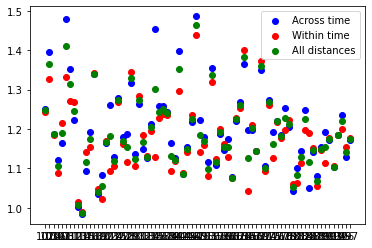

In [11]:
import matplotlib.pyplot as plt

# Assuming 'value' is your second dictionary
#value = {...}

# Create a list of keys and values for each dictionary
keys = list(mean_dataframes_norm_all_minus_time.keys())
mean_dataframes_norm_all_minus_time_values = list(mean_dataframes_norm_all_minus_time.values())
mean_dataframes_timecombined_norm_values = [mean_dataframes_timecombined_norm[key] for key in keys]
mean_dataframes_norm_all_values = [mean_dataframes_norm_all[key] for key in keys]

# Create a new figure
plt.figure()

# Plot the values of each dictionary
plt.scatter(keys, mean_dataframes_norm_all_minus_time_values, color='blue', label='Across time')
plt.scatter(keys, mean_dataframes_timecombined_norm_values, color='red', label='Within time')
plt.scatter(keys, mean_dataframes_norm_all_values, color='green', label='All distances')

# Add a legend
plt.legend()

# Display the plot
plt.show()


In [18]:
# Create a DataFrame
df = pd.DataFrame({
    'dist_across_time': pd.Series(mean_dataframes_norm_all_minus_time),
    'dist_within_time': pd.Series(mean_dataframes_timecombined_norm),
    'dist_all': pd.Series(mean_dataframes_norm_all),
    'dist_within_group': pd.Series(mean_dataframes_groupcombined_norm) #see below
    #last time from #### Input/actual distance for travel groups (A,B,C,D) below
})

# Print the DataFrame
print(df)

     dist_across_time  dist_within_time  dist_all  dist_within_group
102          1.251866          1.242943  1.247702           1.068692
103          1.396220          1.327110  1.363969           1.114057
104          1.187150          1.185895  1.186564           1.187628
106          1.121960          1.089056  1.106605           1.033790
107          1.165229          1.215745  1.188803           1.216908
..                ...               ...       ...                ...
193          1.103557          1.104925  1.104195           1.059770
194          1.184698          1.185522  1.185083           1.096409
195          1.236785          1.200350  1.219782           1.123333
196          1.129302          1.155024  1.141306           1.135989
197          1.173330          1.177608  1.175327           1.166894

[76 rows x 4 columns]


dist_across_time    1.198192
dist_within_time    1.177444
dist_all            1.188510
dtype: float64


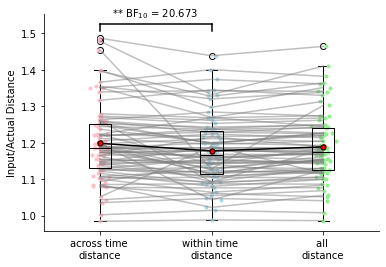

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter

# Assuming 'results_df' is your DataFrame
#result12_df = result1_df[['DD_mean', 'DS_mean', 'SS_mean']]
result12_df = df[['dist_across_time', 'dist_within_time', 'dist_all']]

# Create a box plot for each column
positions = [0, 1, 2]
for i, col in enumerate(result12_df.columns):
    plt.boxplot(result12_df[col], positions=[positions[i]], widths=0.2, patch_artist=True,
                boxprops=dict(facecolor='none', edgecolor='black'),
                whiskerprops=dict(color='black'),
                capprops=dict(color='black'),
                medianprops=dict(color='black'))

# Add a scatter plot for each column
scatter_colors = ['pink', 'lightblue', 'lightgreen']
#scatter_colors = ['pink', 'blue', 'green']
for i, col in enumerate(result12_df.columns):
    y = result12_df[col]
    x = np.random.normal(positions[i], 0.04, size=len(y))  # add jitter to the x-coordinate
    plt.plot(x, y, '.', color=scatter_colors[i], alpha=1)

# Add lines connecting the values in the same row
for i in range(len(result12_df)):
    plt.plot(positions, result12_df.iloc[i], color='gray', alpha=0.5)


# Add significance bar
y_max = result12_df[['dist_across_time', 'dist_within_time']].max().max()  # find maximum y value for the bar
plt.plot([0, 1], [y_max + 0.04, y_max + 0.04], color='black')  # draw a horizontal line
#plt.plot([1.4, 2], [y_max + 2, y_max + 2], color='black')  # draw a horizontal line
plt.text(0.5, y_max + 0.06, "** BF$_{10}$ = 20.673 ", ha='center')  # add a text label for significance

# Define a function to format y-axis labels as percentages
#def to_percent(y, position):
    #return '{:.0f}%'.format(y)

# Create a formatter object
#formatter = FuncFormatter(to_percent)

# Apply the formatter to the y-axis
#plt.gca().yaxis.set_major_formatter(formatter)

# Remove graph borders
sns.despine()

# Add y axis title
plt.ylabel('Input/Actual Distance')

# Add graph heading
#plt.title('Distance comparison')

plt.xticks([0, 1, 2], ['across time \ndistance', 'within time \ndistance', 'all \ndistance'])

# Calculate the means
means = result12_df.mean()
print(means)

# Add a line plot connecting the means
plt.plot(positions, means, color='black', marker='o', markersize=5, markerfacecolor='red')

# Highlight the means as red dots
plt.scatter(positions, means, color='red')

plt.plot([0,0], [y_max+0.02, y_max+0.04], color='black')  # Add vertical line at x=1.4 between y=1.2 and y=1.4
plt.plot([1, 1], [y_max+0.02, y_max+0.04], color='black')  # Add vertical line at x=1.4 between y=1.2 and y=1.4

# Turn off the grid
plt.grid(False)

# Save the figure
plt.savefig('mapping_0512.svg', format='svg')

plt.show()


In [122]:
df.to_csv('mapping_v1.csv', index=False)

#### Actual distance for travel groups (A,B,C,D)

In [13]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist, squareform

# Define a function to calculate average distance
def average_distance(df):
    #coordinates_input = df[['input_location_x', 'input_location_z']].values
    #distances_input = squareform(pdist(coordinates_input))
    coordinates_actual = df[['location_x', 'location_z']].values
    distances_actual = squareform(pdist(coordinates_actual))
    #distances_norm = distances_input/distances_actual
    #print('Distances_input:', distances_input)
    print('Distances_actual:', distances_actual)
    #print('Distances_norm:', distances_norm)
    #print('Number of values in distances_input:', np.size(distances_input))
    print('Number of values in distances_actual:', np.size(distances_actual))
    #print('Number of values in distances_norm:', np.size(distances_norm))
    sum_distances = np.nansum(distances_actual)
    return sum_distances / 12

# Group the DataFrame by 'time' and apply the function
#average_distances = df.groupby('time').apply(average_distance)

# Create an empty dictionary to store the mean data frames
mean_dataframes_group_actual = {}

# Loop through the keys and values in the new_dataframes dictionary
for key, value in new_dataframes.items():
    
    # Group the DataFrame by 'time' and apply the function
    average_distances = value.groupby('group').apply(average_distance)
    mean_dataframes_group_actual[key] = average_distances
    

# Print the number of mean data frames created
print(f"Created {len(mean_dataframes_group_actual)} mean data frames.")

Distances_actual: [[  0.          89.31965069  74.6860094  153.15351775]
 [ 89.31965069   0.          60.46486583  74.6860094 ]
 [ 74.6860094   60.46486583   0.          89.31965069]
 [153.15351775  74.6860094   89.31965069   0.        ]]
Number of values in distances_actual: 16
Distances_actual: [[  0.         126.14277625  99.60923652  45.54119015]
 [126.14277625   0.          45.54119015  99.60923652]
 [ 99.60923652  45.54119015   0.          89.88882022]
 [ 45.54119015  99.60923652  89.88882022   0.        ]]
Number of values in distances_actual: 16
Distances_actual: [[  0.          89.88882022  45.54119015  99.60923652]
 [ 89.88882022   0.          99.60923652  45.54119015]
 [ 45.54119015  99.60923652   0.         126.14277625]
 [ 99.60923652  45.54119015 126.14277625   0.        ]]
Number of values in distances_actual: 16
Distances_actual: [[  0.          89.31965069 153.15351775  74.6860094 ]
 [ 89.31965069   0.          74.6860094   60.46486583]
 [153.15351775  74.6860094    0.

Distances_actual: [[  0.          45.54119015  99.60923652  89.88882022]
 [ 45.54119015   0.         126.14277625  99.60923652]
 [ 99.60923652 126.14277625   0.          45.54119015]
 [ 89.88882022  99.60923652  45.54119015   0.        ]]
Number of values in distances_actual: 16
Distances_actual: [[  0.          89.31965069  74.6860094  153.15351775]
 [ 89.31965069   0.          60.46486583  74.6860094 ]
 [ 74.6860094   60.46486583   0.          89.31965069]
 [153.15351775  74.6860094   89.31965069   0.        ]]
Number of values in distances_actual: 16
Distances_actual: [[  0.          60.46486583  89.31965069  74.6860094 ]
 [ 60.46486583   0.          74.6860094   89.31965069]
 [ 89.31965069  74.6860094    0.         153.15351775]
 [ 74.6860094   89.31965069 153.15351775   0.        ]]
Number of values in distances_actual: 16
Distances_actual: [[  0.          45.54119015  89.88882022  99.60923652]
 [ 45.54119015   0.          99.60923652 126.14277625]
 [ 89.88882022  99.60923652   0.

In [14]:
mean_dataframes_group_actual

{'102': group
 A    90.271617
 B    84.388742
 C    84.388742
 D    90.271617
 dtype: float64,
 '103': group
 A    90.271617
 B    84.388742
 C    84.388742
 D    90.271617
 dtype: float64,
 '104': group
 A    90.271617
 B    84.388742
 C    84.388742
 D    90.271617
 dtype: float64,
 '106': group
 A    90.271617
 B    84.388742
 C    84.388742
 D    90.271617
 dtype: float64,
 '107': group
 A    90.271617
 B    84.388742
 C    84.388742
 D    90.271617
 dtype: float64,
 '108': group
 A    90.271617
 B    84.388742
 C    84.388742
 D    90.271617
 dtype: float64,
 '111': group
 A    90.271617
 B    84.388742
 C    84.388742
 D    90.271617
 dtype: float64,
 '112': group
 A    90.271617
 B    84.388742
 C    84.388742
 D    90.271617
 dtype: float64,
 '113': group
 A    90.271617
 B    84.388742
 C    84.388742
 D    90.271617
 dtype: float64,
 '114': group
 A    90.271617
 B    84.388742
 C    84.388742
 D    90.271617
 dtype: float64,
 '115': group
 A    90.271617
 B    84.388742
 C  

#### Input distance for travel groups (A,B,C,D)

In [15]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist, squareform

# Define a function to calculate average distance
def average_distance(df):
    coordinates_input = df[['input_location_x', 'input_location_z']].values
    distances_input = squareform(pdist(coordinates_input))
    #coordinates_actual = df[['location_x', 'location_z']].values
    #distances_actual = squareform(pdist(coordinates_actual))
    #distances_norm = distances_input/distances_actual
    print('Distances_input:', distances_input)
    #print('Distances_actual:', distances_actual)
    #print('Distances_norm:', distances_norm)
    print('Number of values in distances_input:', np.size(distances_input))
    #print('Number of values in distances_actual:', np.size(distances_actual))
    #print('Number of values in distances_norm:', np.size(distances_norm))
    sum_distances = np.nansum(distances_input)
    return sum_distances / 12

# Group the DataFrame by 'time' and apply the function
#average_distances = df.groupby('time').apply(average_distance)

# Create an empty dictionary to store the mean data frames
mean_dataframes_group_input = {}

# Loop through the keys and values in the new_dataframes dictionary
for key, value in new_dataframes.items():
    
    # Group the DataFrame by 'time' and apply the function
    average_distances = value.groupby('group').apply(average_distance)
    mean_dataframes_group_input[key] = average_distances
    

# Print the number of mean data frames created
print(f"Created {len(mean_dataframes_group_input)} mean data frames.")

Distances_input: [[  0.         109.18892351  95.96910969 186.20567324]
 [109.18892351   0.          57.31550979  84.04896854]
 [ 95.96910969  57.31550979   0.          99.51614154]
 [186.20567324  84.04896854  99.51614154   0.        ]]
Number of values in distances_input: 16
Distances_input: [[  0.         139.69521516 114.64467689  33.71656158]
 [139.69521516   0.          40.80994756 110.79649986]
 [114.64467689  40.80994756   0.          92.31776793]
 [ 33.71656158 110.79649986  92.31776793   0.        ]]
Number of values in distances_input: 16
Distances_input: [[  0.          91.11669601  26.89032383  92.28669921]
 [ 91.11669601   0.          93.33704022  45.90144067]
 [ 26.89032383  93.33704022   0.         106.59174231]
 [ 92.28669921  45.90144067 106.59174231   0.        ]]
Number of values in distances_input: 16
Distances_input: [[  0.         103.60597478 192.39395571  97.89888518]
 [103.60597478   0.          99.69569226  68.07368659]
 [192.39395571  99.69569226   0.       

In [16]:
mean_dataframes_group_input

{'102': group
 A    105.374054
 B     88.663445
 C     76.020657
 D    111.408935
 dtype: float64,
 '103': group
 A     84.046067
 B     85.155358
 C    102.922075
 D     79.116035
 dtype: float64,
 '104': group
 A    108.128807
 B    101.625068
 C     96.555676
 D    106.350098
 dtype: float64,
 '106': group
 A    96.829113
 B    89.610604
 C    88.963493
 D    97.108351
 dtype: float64,
 '107': group
 A    103.501590
 B     98.244004
 C    107.530529
 D    107.524934
 dtype: float64,
 '108': group
 A    101.853132
 B     51.093338
 C     99.134842
 D    101.165670
 dtype: float64,
 '111': group
 A    105.444440
 B    102.659007
 C    103.015417
 D    115.801803
 dtype: float64,
 '112': group
 A    106.186951
 B     96.902329
 C     93.342013
 D    110.577071
 dtype: float64,
 '113': group
 A    88.460783
 B    81.087245
 C    78.169537
 D    93.102731
 dtype: float64,
 '114': group
 A    80.602607
 B    80.193659
 C    68.791662
 D    91.547444
 dtype: float64,
 '115': group
 A    98

#### Input/actual distance for travel groups (A,B,C,D)

In [17]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist, squareform

# Define a function to calculate average distance
def average_distance(df):
    coordinates_input = df[['input_location_x', 'input_location_z']].values
    distances_input = squareform(pdist(coordinates_input))
    coordinates_actual = df[['location_x', 'location_z']].values
    distances_actual = squareform(pdist(coordinates_actual))
    distances_norm = distances_input/distances_actual
    print('Distances_input:', distances_input)
    print('Distances_actual:', distances_actual)
    print('Distances_norm:', distances_norm)
    print('Number of values in distances_input:', np.size(distances_input))
    print('Number of values in distances_actual:', np.size(distances_actual))
    print('Number of values in distances_norm:', np.size(distances_norm))
    sum_distances = np.nansum(distances_norm)
    return sum_distances / 12

# Group the DataFrame by 'time' and apply the function
#average_distances = df.groupby('time').apply(average_distance)

# Create an empty dictionary to store the mean data frames
mean_dataframes_group_norm = {}
sum_dataframes_groupcombined_norm = {}
mean_dataframes_groupcombined_norm = {}

# Loop through the keys and values in the new_dataframes dictionary
for key, value in new_dataframes.items():
    
    # Group the DataFrame by 'time' and apply the function
    average_distances = value.groupby('group').apply(average_distance)
    mean_dataframes_group_norm[key] = average_distances
    sum_dataframes_groupcombined_norm[key] =  np.nansum(mean_dataframes_group_norm[key])
    mean_dataframes_groupcombined_norm = {key: value / 4 for key, value in sum_dataframes_groupcombined_norm.items()}
    

# Print the number of mean data frames created
print(f"Created {len(mean_dataframes_group_norm)} mean data frames.")

/tmp/ipykernel_752/2958831926.py:11: RuntimeWarning: invalid value encountered in divide
  distances_norm = distances_input/distances_actual
/tmp/ipykernel_752/2958831926.py:11: RuntimeWarning: invalid value encountered in divide
  distances_norm = distances_input/distances_actual
/tmp/ipykernel_752/2958831926.py:11: RuntimeWarning: invalid value encountered in divide
  distances_norm = distances_input/distances_actual
/tmp/ipykernel_752/2958831926.py:11: RuntimeWarning: invalid value encountered in divide
  distances_norm = distances_input/distances_actual
/tmp/ipykernel_752/2958831926.py:11: RuntimeWarning: invalid value encountered in divide
  distances_norm = distances_input/distances_actual
/tmp/ipykernel_752/2958831926.py:11: RuntimeWarning: invalid value encountered in divide
  distances_norm = distances_input/distances_actual
/tmp/ipykernel_752/2958831926.py:11: RuntimeWarning: invalid value encountered in divide
  distances_norm = distances_input/distances_actual
/tmp/ipykerne

Distances_input: [[  0.         109.18892351  95.96910969 186.20567324]
 [109.18892351   0.          57.31550979  84.04896854]
 [ 95.96910969  57.31550979   0.          99.51614154]
 [186.20567324  84.04896854  99.51614154   0.        ]]
Distances_actual: [[  0.          89.31965069  74.6860094  153.15351775]
 [ 89.31965069   0.          60.46486583  74.6860094 ]
 [ 74.6860094   60.46486583   0.          89.31965069]
 [153.15351775  74.6860094   89.31965069   0.        ]]
Distances_norm: [[       nan 1.2224513  1.2849677  1.21581062]
 [1.2224513         nan 0.94791428 1.1253643 ]
 [1.2849677  0.94791428        nan 1.11415731]
 [1.21581062 1.1253643  1.11415731        nan]]
Number of values in distances_input: 16
Number of values in distances_actual: 16
Number of values in distances_norm: 16
Distances_input: [[  0.         139.69521516 114.64467689  33.71656158]
 [139.69521516   0.          40.80994756 110.79649986]
 [114.64467689  40.80994756   0.          92.31776793]
 [ 33.71656158 1

Distances_input: [[ 0.         62.43048899 41.30255557 67.13503366]
 [62.43048899  0.         54.77856527 60.77762024]
 [41.30255557 54.77856527  0.         26.07745586]
 [67.13503366 60.77762024 26.07745586  0.        ]]
Distances_actual: [[  0.          60.46486583  74.6860094   89.31965069]
 [ 60.46486583   0.          89.31965069  74.6860094 ]
 [ 74.6860094   89.31965069   0.         153.15351775]
 [ 89.31965069  74.6860094  153.15351775   0.        ]]
Distances_norm: [[       nan 1.03250852 0.55301597 0.75162669]
 [1.03250852        nan 0.61328683 0.81377517]
 [0.55301597 0.61328683        nan 0.17027004]
 [0.75162669 0.81377517 0.17027004        nan]]
Number of values in distances_input: 16
Number of values in distances_actual: 16
Number of values in distances_norm: 16
Distances_input: [[ 0.         14.55354978 73.98032884 64.71757929]
 [14.55354978  0.         67.08849599 59.46080065]
 [73.98032884 67.08849599  0.         11.78511538]
 [64.71757929 59.46080065 11.78511538  0.   

/tmp/ipykernel_752/2958831926.py:11: RuntimeWarning: invalid value encountered in divide
  distances_norm = distances_input/distances_actual
/tmp/ipykernel_752/2958831926.py:11: RuntimeWarning: invalid value encountered in divide
  distances_norm = distances_input/distances_actual
/tmp/ipykernel_752/2958831926.py:11: RuntimeWarning: invalid value encountered in divide
  distances_norm = distances_input/distances_actual
/tmp/ipykernel_752/2958831926.py:11: RuntimeWarning: invalid value encountered in divide
  distances_norm = distances_input/distances_actual
/tmp/ipykernel_752/2958831926.py:11: RuntimeWarning: invalid value encountered in divide
  distances_norm = distances_input/distances_actual
/tmp/ipykernel_752/2958831926.py:11: RuntimeWarning: invalid value encountered in divide
  distances_norm = distances_input/distances_actual
/tmp/ipykernel_752/2958831926.py:11: RuntimeWarning: invalid value encountered in divide
  distances_norm = distances_input/distances_actual
/tmp/ipykerne

In [117]:
mean_dataframes_group_norm

{'102': group
 A    1.151778
 B    1.005696
 C    0.886760
 D    1.230536
 dtype: float64,
 '103': group
 A    1.020113
 B    1.023192
 C    1.457447
 D    0.955477
 dtype: float64,
 '104': group
 A    1.226475
 B    1.186225
 C    1.143687
 D    1.194127
 dtype: float64,
 '106': group
 A    1.047651
 B    1.021924
 C    1.009323
 D    1.056262
 dtype: float64,
 '107': group
 A    1.149390
 B    1.138638
 C    1.364699
 D    1.214905
 dtype: float64,
 '108': group
 A    1.123098
 B    0.764312
 C    1.338499
 D    1.062648
 dtype: float64,
 '111': group
 A    1.153091
 B    1.155469
 C    1.104181
 D    1.287743
 dtype: float64,
 '112': group
 A    1.170653
 B    1.157747
 C    1.117046
 D    1.212874
 dtype: float64,
 '113': group
 A    0.974903
 B    0.923964
 C    0.870404
 D    1.048827
 dtype: float64,
 '114': group
 A    0.932709
 B    1.043237
 C    1.029398
 D    1.050780
 dtype: float64,
 '115': group
 A    1.063128
 B    0.801916
 C    0.795926
 D    1.025071
 dtype: float64,

In [119]:
sum_dataframes_groupcombined_norm

{'102': 4.274769663518466,
 '103': 4.4562289970511255,
 '104': 4.750513357092313,
 '106': 4.135159890680152,
 '107': 4.86763284068101,
 '108': 4.288557675155296,
 '111': 4.700483051188661,
 '112': 4.658320345558121,
 '113': 3.8180978579134726,
 '114': 4.056123521062992,
 '115': 3.6860400285957535,
 '116': 4.700784117454863,
 '118': 4.54208172078441,
 '119': 3.9713870129000846,
 '120': 4.201294547904303,
 '121': 3.989393678848562,
 '123': 4.172107193067577,
 '124': 4.2521068935417965,
 '125': 4.319404756187529,
 '127': 4.881275328556601,
 '128': 4.179643480378697,
 '129': 4.145637799643032,
 '130': 4.337566816996262,
 '131': 4.3339300331098976,
 '132': 4.36007779241908,
 '133': 3.197616061800434,
 '134': 4.704599782711122,
 '135': 4.363335995372551,
 '136': 4.996892381592147,
 '137': 5.027806851234882,
 '138': 4.74770341845318,
 '139': 4.049756952444853,
 '141': 4.222633934031003,
 '142': 4.865486776153137,
 '144': 4.352042495816952,
 '145': 4.644617544145826,
 '146': 4.674050318716606,

In [120]:
mean_dataframes_groupcombined_norm

{'102': 1.0686924158796165,
 '103': 1.1140572492627814,
 '104': 1.1876283392730782,
 '106': 1.033789972670038,
 '107': 1.2169082101702524,
 '108': 1.072139418788824,
 '111': 1.1751207627971652,
 '112': 1.1645800863895301,
 '113': 0.9545244644783681,
 '114': 1.014030880265748,
 '115': 0.9215100071489384,
 '116': 1.1751960293637158,
 '118': 1.1355204301961026,
 '119': 0.9928467532250211,
 '120': 1.0503236369760758,
 '121': 0.9973484197121405,
 '123': 1.0430267982668942,
 '124': 1.0630267233854491,
 '125': 1.0798511890468823,
 '127': 1.2203188321391503,
 '128': 1.0449108700946743,
 '129': 1.036409449910758,
 '130': 1.0843917042490654,
 '131': 1.0834825082774744,
 '132': 1.09001944810477,
 '133': 0.7994040154501085,
 '134': 1.1761499456777804,
 '135': 1.0908339988431377,
 '136': 1.2492230953980368,
 '137': 1.2569517128087204,
 '138': 1.186925854613295,
 '139': 1.0124392381112133,
 '141': 1.0556584835077507,
 '142': 1.2163716940382843,
 '144': 1.088010623954238,
 '145': 1.1611543860364566,


### Modeling

In [20]:
import statsmodels.api as sm
import numpy as np

# Let's assume these are your actual and estimated distances
actual_distances = np.array([1, 2, 3, 4, 5])
estimated_distances = np.array([1.1, 2.2, 2.8, 4.5, 4.8])

# Add a constant to the actual_distances array for the linear regression intercept
X = sm.add_constant(actual_distances)

# Build the model
model = sm.OLS(estimated_distances, X)

# Fit the model
results = model.fit()

# Print out the statistics
print(results.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                     83.27
Date:                Thu, 14 Dec 2023   Prob (F-statistic):            0.00278
Time:                        22:28:57   Log-Likelihood:               -0.36671
No. Observations:                   5   AIC:                             4.733
Df Residuals:                       3   BIC:                             3.952
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1700      0.353      0.482      0.6

/home/dragon/.local/lib/python3.8/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [21]:
#result12_df = df[['dist_across_time', 'dist_within_time', 'dist_all']]

import statsmodels.api as sm
import numpy as np

# Let's assume these are your actual and estimated distances
#actual_distances = np.ones(76)
actual_distances = df[['dist_within_time']]
estimated_distances = df[['dist_across_time']]

# Add a constant to the actual_distances array for the linear regression intercept
X = sm.add_constant(actual_distances)

# Build the model
model = sm.OLS(estimated_distances, X)

# Fit the model
results = model.fit()

# Print out the statistics
print(results.summary())


                            OLS Regression Results                            
Dep. Variable:       dist_across_time   R-squared:                       0.684
Model:                            OLS   Adj. R-squared:                  0.680
Method:                 Least Squares   F-statistic:                     160.4
Date:                Thu, 14 Dec 2023   Prob (F-statistic):           3.28e-20
Time:                        22:29:01   Log-Likelihood:                 108.80
No. Observations:                  76   AIC:                            -213.6
Df Residuals:                      74   BIC:                            -208.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.1075      0.086  

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.684
Model:                            OLS   Adj. R-squared:                  0.680
Method:                 Least Squares   F-statistic:                     160.4
Date:                Tue, 05 Dec 2023   Prob (F-statistic):           3.28e-20
Time:                        00:47:38   Log-Likelihood:                 108.80
No. Observations:                  76   AIC:                            -213.6
Df Residuals:                      74   BIC:                            -208.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1075      0.086      1.245      0.2

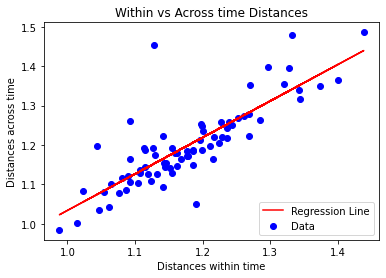

In [25]:
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt

# Let's assume these are your actual and estimated distances
actual_distances = df[['dist_within_time']].values
estimated_distances = df[['dist_across_time']].values

# Add a constant to the actual_distances array for the linear regression intercept
X = sm.add_constant(actual_distances)

# Build the model
model = sm.OLS(estimated_distances, X)

# Fit the model
results = model.fit()

# Print out the statistics
print(results.summary())

# Create a scatter plot of the actual vs estimated distances
plt.scatter(actual_distances, estimated_distances, color='blue', label='Data')

# Create a line plot of the actual distances vs the predicted distances
plt.plot(actual_distances, results.predict(X), color='red', label='Regression Line')

# Add labels and title
plt.xlabel('Distances within time')
plt.ylabel('Distances across time')
plt.title('Within vs Across time Distances')
plt.legend()

# Save the figure
plt.savefig('mapping_ols_0512.svg', format='svg')

# Show the plot
plt.show()




                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.684
Model:                            OLS   Adj. R-squared:                  0.680
Method:                 Least Squares   F-statistic:                     160.4
Date:                Thu, 14 Dec 2023   Prob (F-statistic):           3.28e-20
Time:                        22:29:25   Log-Likelihood:                 108.80
No. Observations:                  76   AIC:                            -213.6
Df Residuals:                      74   BIC:                            -208.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1075      0.086      1.245      0.2

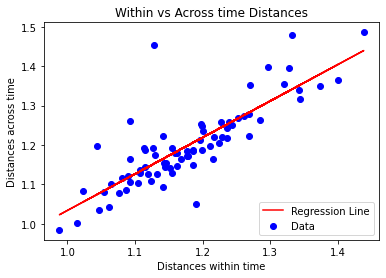

In [22]:
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt

# Let's assume these are your actual and estimated distances
actual_distances = df[['dist_within_time']].values
estimated_distances = df[['dist_across_time']].values

# Add a constant to the actual_distances array for the linear regression intercept
X = sm.add_constant(actual_distances)

# Build the model
model = sm.OLS(estimated_distances, X)

# Fit the model
results = model.fit()

# Print out the statistics
print(results.summary())

# Calculate and print the covariance
covariance = np.cov(actual_distances.T, estimated_distances.T)[0, 1]
print(f"Covariance: {covariance}")

# Create a scatter plot of the actual vs estimated distances
plt.scatter(actual_distances, estimated_distances, color='blue', label='Data')

# Create a line plot of the actual distances vs the predicted distances
plt.plot(actual_distances, results.predict(X), color='red', label='Regression Line')

# Add labels and title
plt.xlabel('Distances within time')
plt.ylabel('Distances across time')
plt.title('Within vs Across time Distances')
plt.legend()

# Save the figure
#plt.savefig('mapping_ols_0512.svg', format='svg')

# Show the plot
plt.show()


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.684
Model:                            OLS   Adj. R-squared:                  0.680
Method:                 Least Squares   F-statistic:                     160.4
Date:                Thu, 14 Dec 2023   Prob (F-statistic):           3.28e-20
Time:                        22:32:02   Log-Likelihood:                 117.39
No. Observations:                  76   AIC:                            -230.8
Df Residuals:                      74   BIC:                            -226.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2922      0.070      4.166      0.0

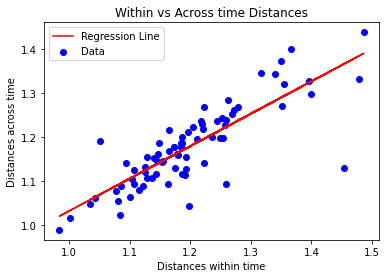

In [24]:
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt

# Let's assume these are your actual and estimated distances
actual_distances = df[['dist_within_time']].values
estimated_distances = df[['dist_across_time']].values

# Add a constant to the actual_distances array for the linear regression intercept
X = sm.add_constant(estimated_distances)

# Build the model
model = sm.OLS(actual_distances, X)

# Fit the model
results = model.fit()

# Print out the statistics
print(results.summary())

# Calculate and print the covariance
covariance = np.cov(actual_distances.T, estimated_distances.T)[0, 1]
print(f"Covariance: {covariance}")

# Create a scatter plot of the actual vs estimated distances
plt.scatter(estimated_distances, actual_distances, color='blue', label='Data')

# Create a line plot of the actual distances vs the predicted distances
plt.plot(estimated_distances, results.predict(X), color='red', label='Regression Line')

# Add labels and title
plt.xlabel('Distances within time')
plt.ylabel('Distances across time')
plt.title('Within vs Across time Distances')
plt.legend()

# Save the figure
#plt.savefig('mapping_ols_0512.svg', format='svg')

# Show the plot
plt.show()


In [25]:
df

,dist_across_time,dist_within_time,dist_all,dist_within_group
102,1.251866,1.242943,1.247702,1.068692
103,1.396220,1.327110,1.363969,1.114057
104,1.187150,1.185895,1.186564,1.187628
106,1.121960,1.089056,1.106605,1.033790
107,1.165229,1.215745,1.188803,1.216908
...,...,...,...,...
193,1.103557,1.104925,1.104195,1.059770
194,1.184698,1.185522,1.185083,1.096409
195,1.236785,1.200350,1.219782,1.123333
196,1.129302,1.155024,1.141306,1.135989


In [124]:
pip install --upgrade statsmodels


     |████████████████████████████████| 10.2 MB 1.5 MB/s eta 0:00:01
ERROR: allensdk 2.15.1 has requirement statsmodels<=0.13.0, but you'll have statsmodels 0.14.0 which is incompatible.
  Attempting uninstall: statsmodels
    Found existing installation: statsmodels 0.13.0
    Uninstalling statsmodels-0.13.0:
      Successfully uninstalled statsmodels-0.13.0
Note: you may need to restart the kernel to use updated packages.


In [126]:
import scipy
print(scipy.__version__)


1.10.1


In [133]:
pip install --upgrade scipy


Requirement already up-to-date: scipy in /home/dragon/.local/lib/python3.8/site-packages (1.10.1)
Note: you may need to restart the kernel to use updated packages.


In [131]:
pip uninstall statsmodels
#pip install statsmodels


SyntaxError: invalid syntax (426559976.py, line 1)

In [132]:
pip install --upgrade numpy

     |████████████████████████████████| 17.3 MB 4.9 MB/s eta 0:00:01
ERROR: tensorflow 2.13.0 has requirement numpy<=1.24.3,>=1.22, but you'll have numpy 1.24.4 which is incompatible.
ERROR: scikit-learn 1.3.0 has requirement joblib>=1.1.1, but you'll have joblib 1.1.0 which is incompatible.
ERROR: scikit-image 0.20.0 has requirement scipy<1.9.2,>=1.8; python_version <= "3.9", but you'll have scipy 1.10.1 which is incompatible.
ERROR: pynwb 2.3.1 has requirement hdmf<4,>=3.5.1, but you'll have hdmf 3.4.7 which is incompatible.
ERROR: pynwb 2.3.1 has requirement numpy<1.24,>=1.16, but you'll have numpy 1.24.4 which is incompatible.
ERROR: pymc3 3.11.5 has requirement numpy<1.22.2,>=1.15.0, but you'll have numpy 1.24.4 which is incompatible.
ERROR: pymc3 3.11.5 has requirement scipy<1.8.0,>=1.7.3, but you'll have scipy 1.10.1 which is incompatible.
ERROR: photonai-graph 0.2.5 has requirement numpy<=1.24.2, but you'll have numpy 1.24.4 which is incompatible.
ERROR: pandas-flavor 0.3.0 has